#Emotion Recognition Project

#Group Members


*   Joshalynn
*   Janil
*   Diego
*   Tina




#Imports

In [ ]:
# !pip -q install gdown
# !pip -q install gdown librosa soundfile

import os, glob, random, math
import numpy as np
import pandas as pd
import librosa
import soundfile as sf
import librosa.display
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# Data Loading

**Downloading The Raw Data**

In [ ]:
# # speech actors
# !gdown --fuzzy "https://drive.google.com/file/d/1Oucj9aJ5ngRK5OXuxgxuVY3AfrJ-L00X/view?usp=sharing" \
#        -O actors_speech.zip

**Dataset Extraction**

In [ ]:
# !unzip -q actors_speech.zip -d actors_speech

#Pre-Processing

In [ ]:
# This is the single shared audio-loading function for the project.
# It does two things:
# 1) Loads every file at a fixed sample rate (16 kHz) for consistency across the dataset.
# 2) Peak-normalizes the waveform so volume scale is comparable between recordings.
# load → normalize → trim silence
#**note that we are goin to had to pad it before throwing it into a classifier

def load_audio(p):
    y, sr = librosa.load(p, sr=16000)          # load at fixed sample rate
    y = librosa.util.normalize(y)              # normalize amplitude
    y, _ = librosa.effects.trim(y, top_db=30)  # remove leading/trailing silence
    return y, sr


#Dataset Structure & Labels

**Ground Truth Table**

In [ ]:
#Label Maps
EMOTION = {
    "01": "neutral", "02": "calm", "03": "happy", "04": "sad",
    "05": "angry", "06": "fearful", "07": "disgust", "08": "surprised"
}
INTENSITY = {"01": "normal", "02": "strong"}

In [ ]:
#Helpers: list WAV files + parse filename → labels
# Find all WAV audio files inside the extracted dataset folders
# ** means search subfolders too (recursive=True)
def list_files():
    return sorted(
        glob.glob("actors_speech/**/*.wav", recursive=True)
    )
# Parse one filename into label fields
# Expected filename pattern: MM-VC-EM-IN-ST-RP-ACT.wav
# We only keep EM (emotion) and IN (intensity) here
def parse_filename_labels(p: str) -> dict:
    parts = os.path.splitext(os.path.basename(p))[0].split("-")

    # If filename not in expected 7-part format → mark invalid
    if len(parts) != 7:
        return {"path": p, "parse_ok": False}

    # Unpack only the fields we care about
    _, _, em_code, int_code, *_ = parts

    return {
        "path": p,                                  # full file path (used later to load audio)
        "parse_ok": True,                           # flag that filename parsed correctly
        "emotion": EMOTION.get(em_code, "unknown"), # decoded emotion label
        "intensity": INTENSITY.get(int_code, "unknown"),  # decoded intensity label
    }

In [ ]:
#Create ground-truth dataframe + export (ground_truth_labels.csv)

# Build dataframe: one row per audio file with labels
df = pd.DataFrame(parse_filename_labels(p) for p in list_files())

# Save labels table for reuse / inspection
df.to_csv("ground_truth_labels.csv", index=False)

# Quick summary so we know parsing worked
print("rows:", len(df), "valid:", int(df["parse_ok"].sum()))


In [ ]:
### Validating audio categories - will delete - diego
import IPython.display as ipd
ipd.Audio(df['path'][0])
df['path'][0]

In [ ]:
# ========= 1) Build paths + labels from df =========
# df must contain: path, parse_ok, emotion, intensity (or label)
df_valid = df[df["parse_ok"]].copy()

# Ensure the combined label exists (emotion + intensity)
if "label" not in df_valid.columns:
    df_valid["label"] = df_valid["emotion"] + "_" + df_valid["intensity"]

# Enforce the rule: no neutral_strong
df_valid = df_valid[df_valid["label"] != "neutral_strong"].reset_index(drop=True)

paths = df_valid["path"].tolist()
labels_str = df_valid["label"].tolist()

print("Total samples:", len(paths))
print("Example:", os.path.basename(paths[0]), "->", labels_str[0])
print("Unique classes:", sorted(set(labels_str)))

In [ ]:
p = df_valid.iloc[0]["path"]

y_raw, sr = librosa.load(p, sr=16000)
y_trim, _ = librosa.effects.trim(y_raw, top_db=30)

print("Raw length:", len(y_raw)/sr, "sec")
print("Trimmed length:", len(y_trim)/sr, "sec")

plt.figure(figsize=(10,3))
librosa.display.waveshow(y_raw, sr=sr)
plt.title("Before Trim")
plt.show()

plt.figure(figsize=(10,3))
librosa.display.waveshow(y_trim, sr=sr)
plt.title("After Trim")
plt.show()



In [ ]:
from IPython.display import Audio

Audio(y_trim, rate=sr)

#Exploratory Data Analysis

In [ ]:
# Quick label distribution checks
df_valid = df[df["parse_ok"]].copy()
display(df_valid["emotion"].value_counts())
display(df_valid["intensity"].value_counts())


In [ ]:
if "label" not in df_valid.columns:
    df_valid["label"] = df_valid["emotion"].astype(str) + "_" + df_valid["intensity"].astype(str)

df_valid

In [ ]:
df_valid["emotion"].value_counts()

# Feature Visualization

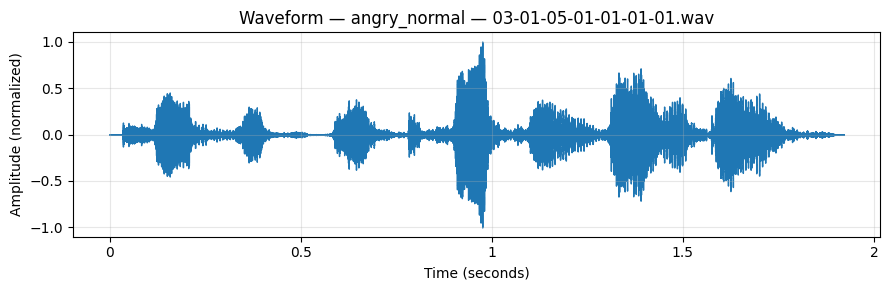

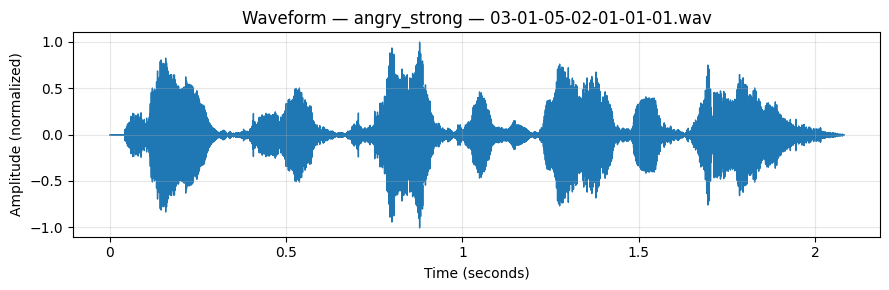

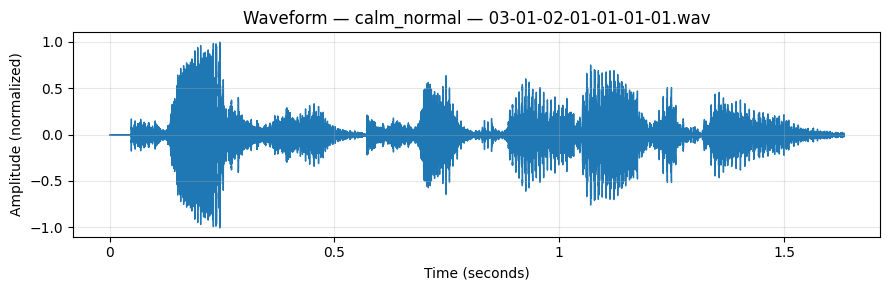

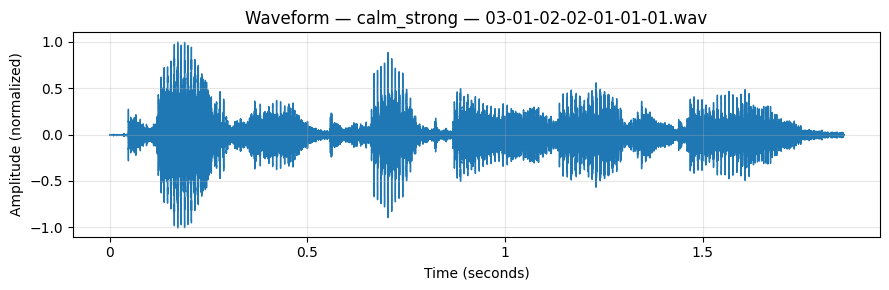

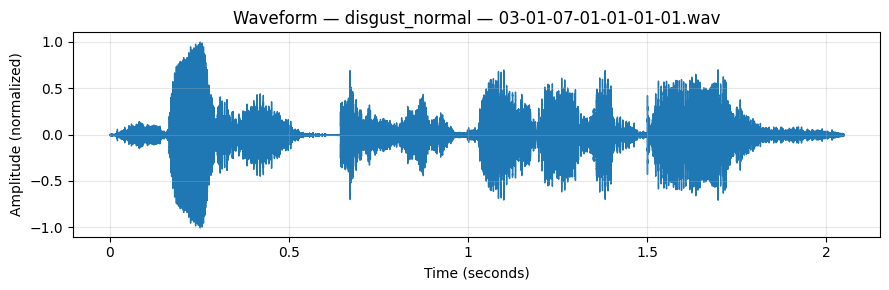

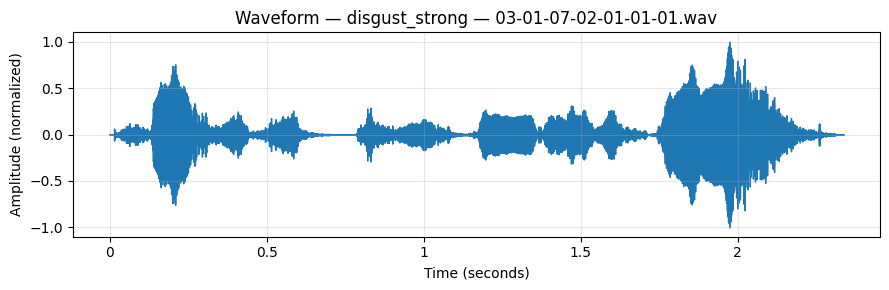

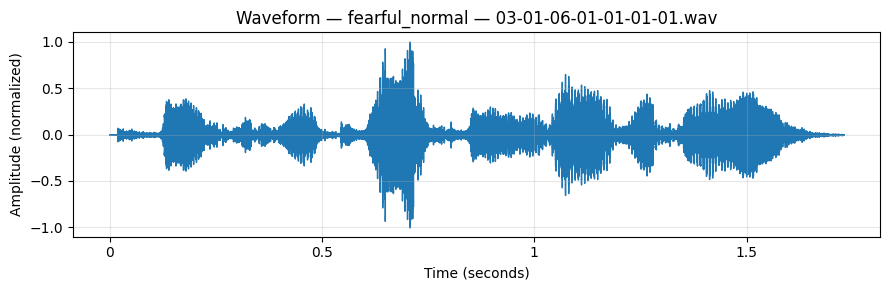

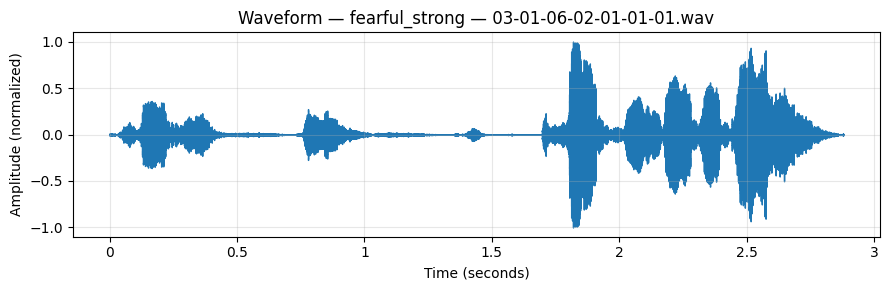

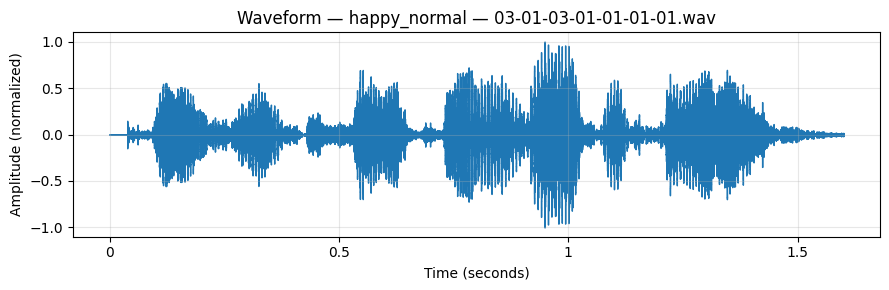

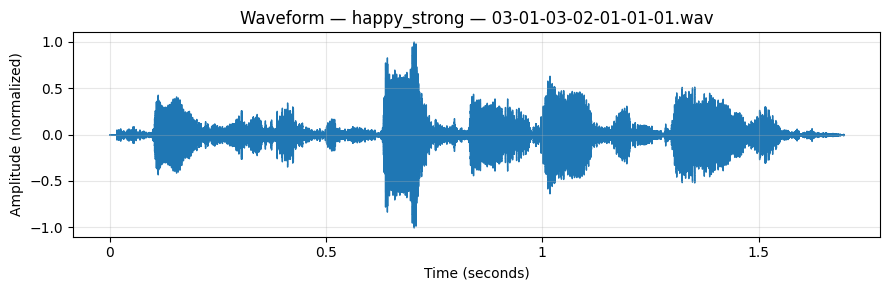

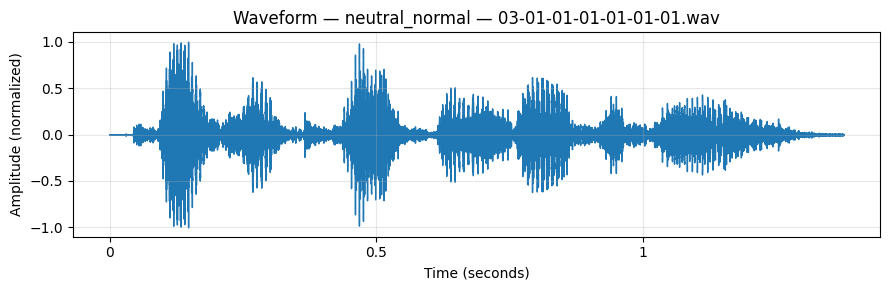

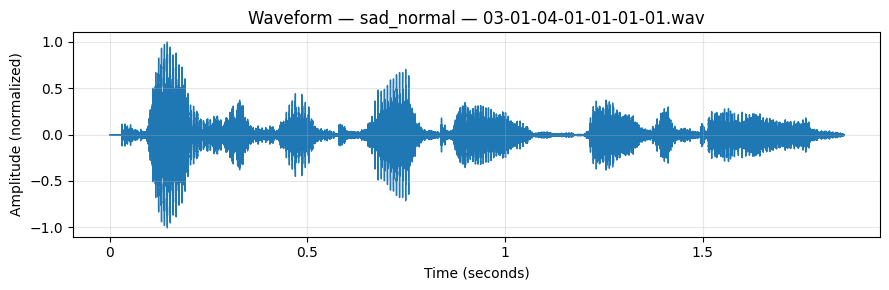

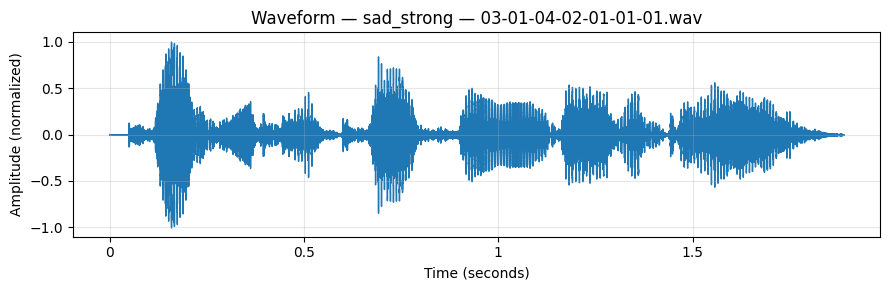

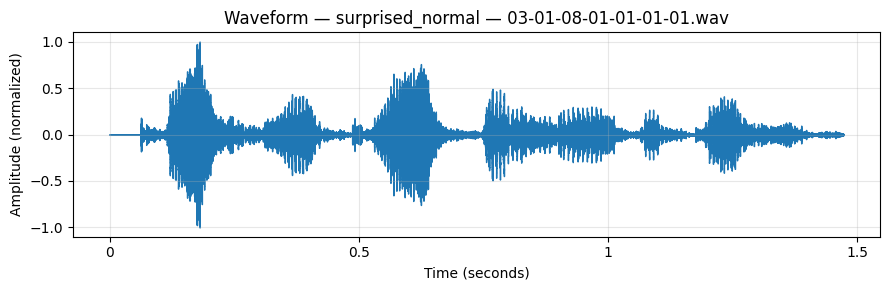

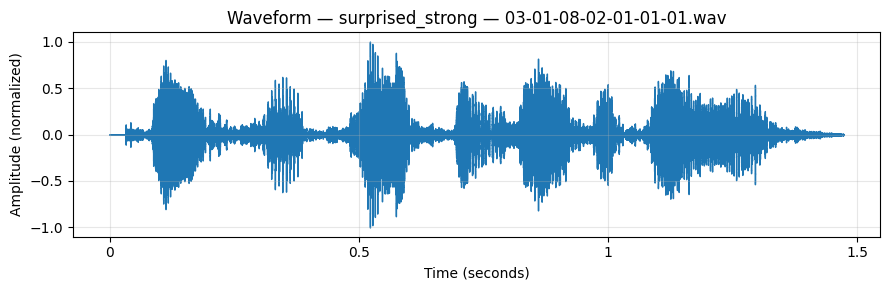

In [15]:
# One sample per (emotion, intensity) + waveform plots

# 1) Ensure combined label exists
if "label" not in df_valid.columns:
    df_valid["label"] = df_valid["emotion"].astype(str) + "_" + df_valid["intensity"].astype(str)

# 2) Pick one per emotion AND intensity
one_per_group = (
    df_valid
    .drop_duplicates(subset=["emotion", "intensity"])
    [["path", "emotion", "intensity", "label"]]
    .sort_values(["emotion", "intensity"])
    .reset_index(drop=True)
)

display(one_per_group)

# 3) Plot waveforms
for _, r in one_per_group.iterrows():
    p = r["path"]
    lab = r["label"]

    y, sr = load_audio(p)  # <-- normalized loading

    plt.figure(figsize=(9, 3))
    librosa.display.waveshow(y, sr=sr)
    plt.title(f"Waveform — {lab} — {os.path.basename(p)}")
    plt.xlabel("Time (seconds)")
    plt.ylabel("Amplitude (normalized)")  # optional but accurate
    plt.grid(alpha=0.3)
    plt.tight_layout()
    # plt.show()


,path,emotion,intensity,label
0,actors_speech/Actor_01/03-01-05-01-01-01-01.wav,angry,normal,angry_normal
1,actors_speech/Actor_01/03-01-05-02-01-01-01.wav,angry,strong,angry_strong
2,actors_speech/Actor_01/03-01-02-01-01-01-01.wav,calm,normal,calm_normal
3,actors_speech/Actor_01/03-01-02-02-01-01-01.wav,calm,strong,calm_strong
4,actors_speech/Actor_01/03-01-07-01-01-01-01.wav,disgust,normal,disgust_normal
5,actors_speech/Actor_01/03-01-07-02-01-01-01.wav,disgust,strong,disgust_strong
6,actors_speech/Actor_01/03-01-06-01-01-01-01.wav,fearful,normal,fearful_normal
7,actors_speech/Actor_01/03-01-06-02-01-01-01.wav,fearful,strong,fearful_strong
8,actors_speech/Actor_01/03-01-03-01-01-01-01.wav,happy,normal,happy_normal
9,actors_speech/Actor_01/03-01-03-02-01-01-01.wav,happy,strong,happy_strong


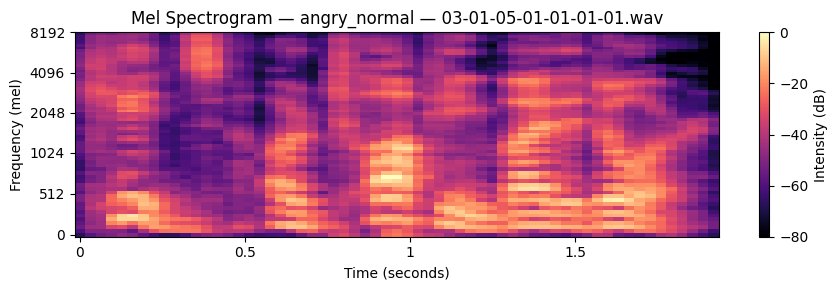

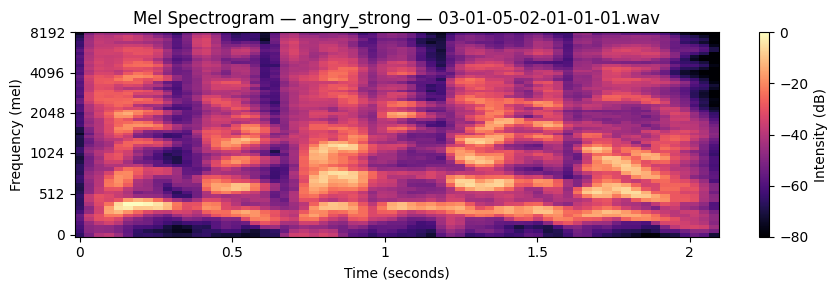

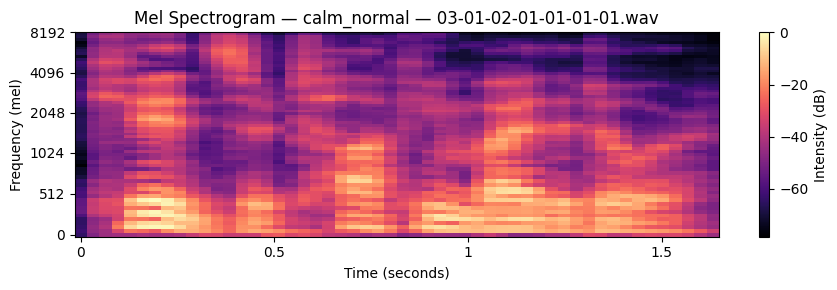

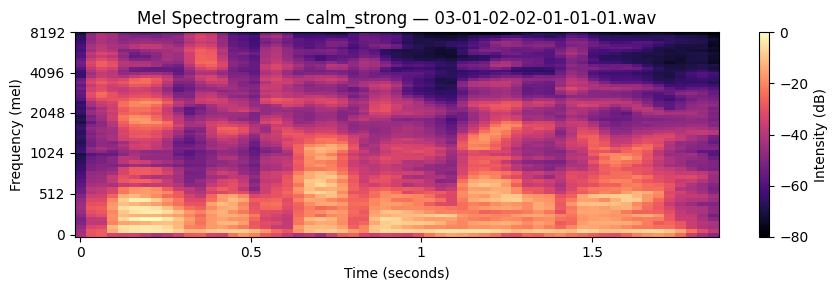

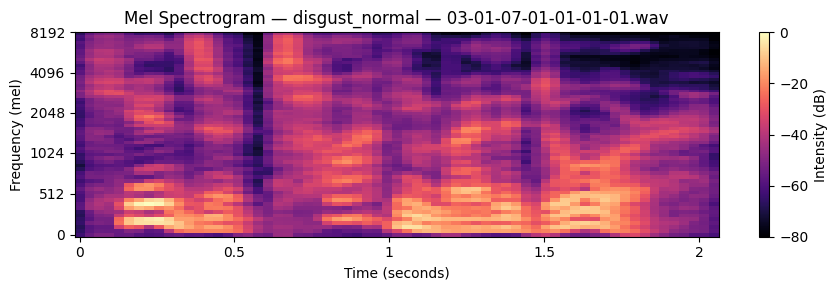

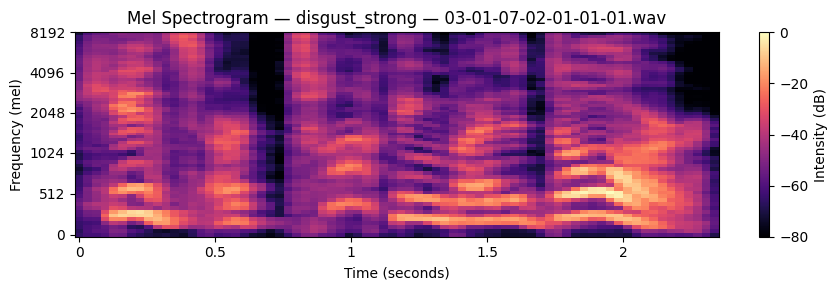

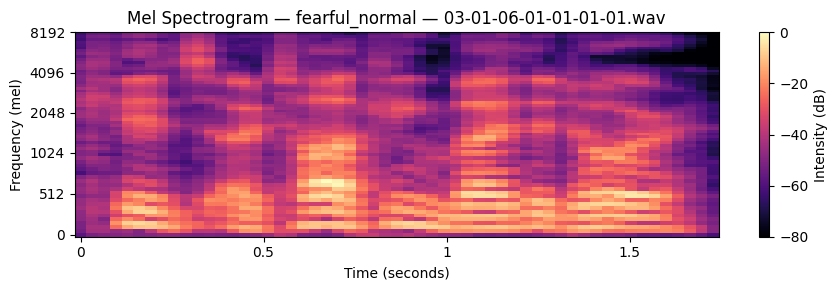

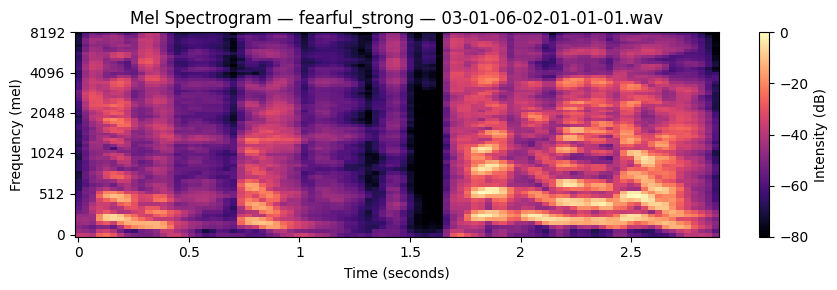

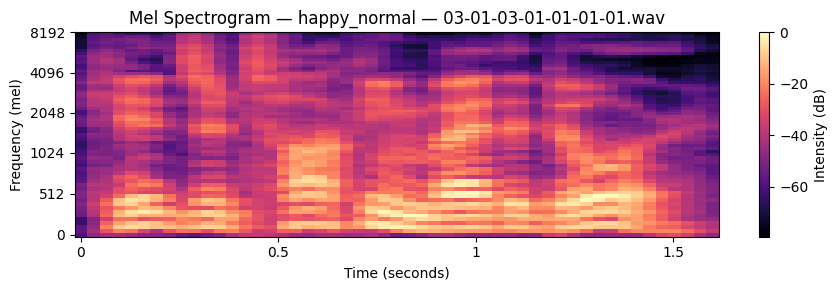

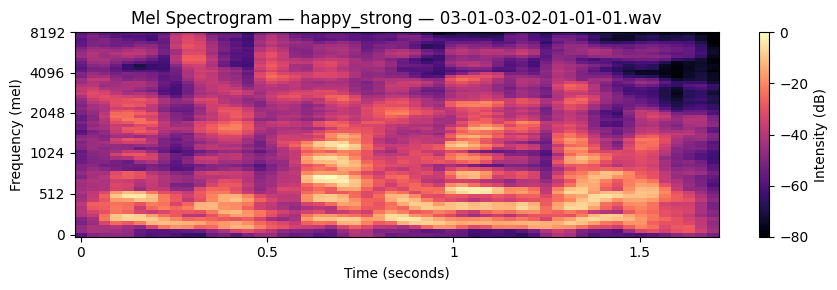

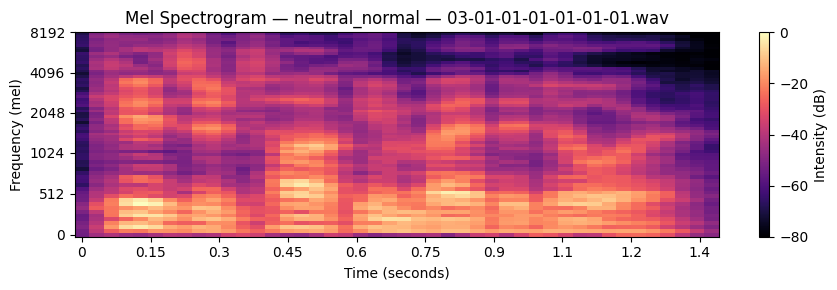

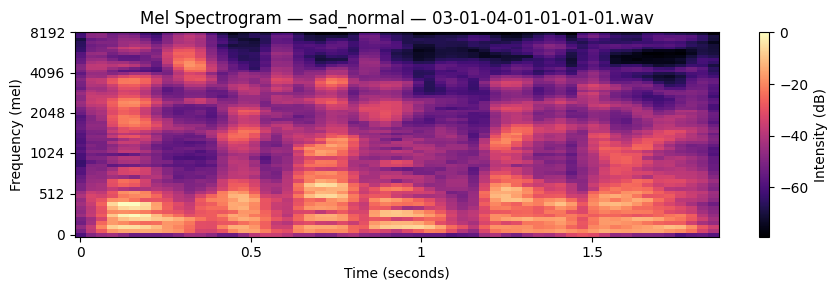

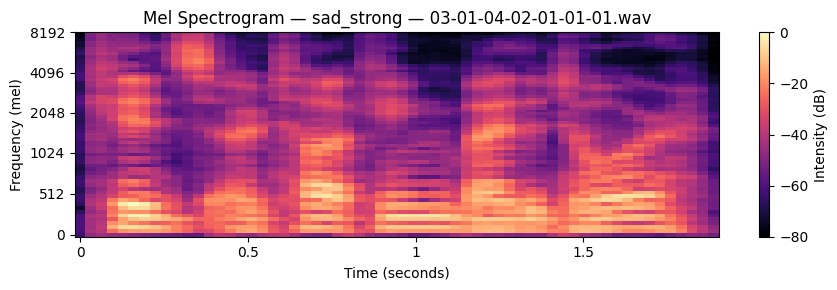

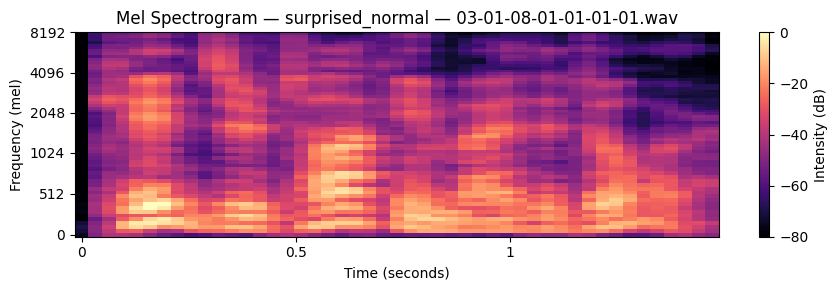

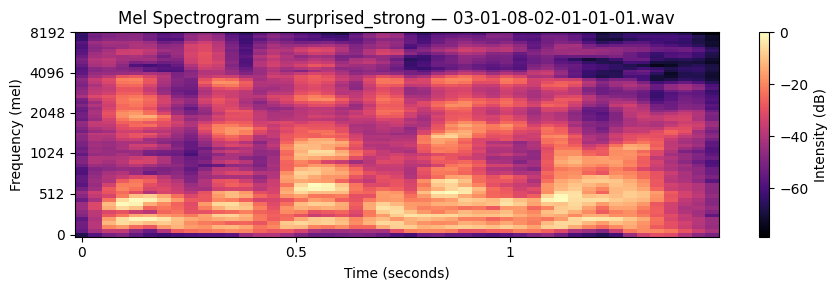

In [16]:
# One Sample per (Emotion, Intensity) — Labeled Spectrogram Plots

# ensure combined label exists
if "label" not in df_valid.columns:
    df_valid["label"] = df_valid["emotion"].astype(str) + "_" + df_valid["intensity"].astype(str)

# pick one file per emotion AND intensity (normal + strong)
one_per_group = (
    df_valid
    .drop_duplicates(subset=["emotion", "intensity"])
    [["path", "emotion", "intensity", "label"]]
    .sort_values(["emotion", "intensity"])
    .reset_index(drop=True)
)

display(one_per_group)

# plot mel spectrograms
for _, r in one_per_group.iterrows():
    p = r["path"]
    lab = r["label"]

    y, sr = load_audio(p)   # ← normalized load

    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=64)
    S_db = librosa.power_to_db(S, ref=np.max)

    plt.figure(figsize=(9, 3))
    librosa.display.specshow(S_db, sr=sr, x_axis="time", y_axis="mel")
    plt.title(f"Mel Spectrogram — {lab} — {os.path.basename(p)}")
    plt.xlabel("Time (seconds)")
    plt.ylabel("Frequency (mel)")
    plt.colorbar(label="Intensity (dB)")
    plt.tight_layout()
    plt.show()


# Pipeline-Driven Feature Engineering EDA

This section rebuilds the feature-engineering pipeline directly inside the notebook so the homework is self-contained.

In this section we will:

- rebuild the metadata table from the official RAVDESS naming convention,
- summarize the actor-wise train/validation/test split,
- extract the handcrafted feature vector used by the hybrid model,
- explain what each feature family represents acoustically,
- visualize interpretable feature distributions across emotions,
- project the handcrafted features into 2D,
- and demonstrate the augmentation pipeline used during training.


In [ ]:
import json
import random
from dataclasses import asdict, dataclass
from pathlib import Path
from typing import Dict, List, Sequence, Tuple

import librosa
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.model_selection import GroupShuffleSplit
from torch import nn
from transformers import AutoModel


RAVDESS_MODALITY_BY_CODE: Dict[int, str] = {
    1: "full_av",
    2: "video_only",
    3: "audio_only",
}

RAVDESS_CHANNEL_BY_CODE: Dict[int, str] = {
    1: "speech",
    2: "song",
}

RAVDESS_EMOTION_BY_CODE: Dict[int, str] = {
    1: "neutral",
    2: "calm",
    3: "happy",
    4: "sad",
    5: "angry",
    6: "fearful",
    7: "disgust",
    8: "surprised",
}

RAVDESS_INTENSITY_BY_CODE: Dict[int, str] = {
    1: "normal",
    2: "strong",
}

RAVDESS_STATEMENT_BY_CODE: Dict[int, str] = {
    1: "kids_are_talking_by_the_door",
    2: "dogs_are_sitting_by_the_door",
}

RAVDESS_REPETITION_BY_CODE: Dict[int, str] = {
    1: "first_repetition",
    2: "second_repetition",
}

FULL_EMOTION_LABELS: Tuple[str, ...] = tuple(
    RAVDESS_EMOTION_BY_CODE[idx] for idx in sorted(RAVDESS_EMOTION_BY_CODE)
)
INTENSITY_LABELS: Tuple[str, ...] = tuple(
    RAVDESS_INTENSITY_BY_CODE[idx] for idx in sorted(RAVDESS_INTENSITY_BY_CODE)
)
TARGET_LABELS: Tuple[str, ...] = ("happy", "sad", "other")


@dataclass(frozen=True)
class AudioConfig:
    sample_rate: int = 16_000
    duration_seconds: float = 4.0

    @property
    def target_num_samples(self) -> int:
        return int(self.sample_rate * self.duration_seconds)


@dataclass(frozen=True)
class FeatureConfig:
    n_mfcc: int = 13
    n_mels: int = 64
    frame_length: int = 1024
    hop_length: int = 256
    n_fft: int = 1024
    mel_fmin: float = 20.0
    mel_fmax: float = 8_000.0
    pitch_fmin: float = 50.0
    pitch_fmax: float = 500.0


@dataclass(frozen=True)
class AugmentConfig:
    noise_prob: float = 0.80
    noise_scale: float = 0.006
    shift_prob: float = 0.70
    shift_max_fraction: float = 0.20
    pitch_prob: float = 0.45
    pitch_max_steps: float = 2.5
    stretch_prob: float = 0.35
    stretch_min_rate: float = 0.85
    stretch_max_rate: float = 1.15
    gain_prob: float = 0.35
    gain_db_min: float = -6.0
    gain_db_max: float = 6.0
    speaker_mix_prob: float = 0.0
    speaker_mix_alpha_min: float = 0.35
    speaker_mix_alpha_max: float = 0.65


@dataclass(frozen=True)
class SampleRecord:
    path: str
    actor_id: int
    modality_code: int
    modality_label: str
    channel_code: int
    channel_label: str
    emotion_code: int
    ravdess_emotion: str
    intensity_code: int
    intensity_label: str
    statement_code: int
    statement_label: str
    repetition_code: int
    repetition_label: str
    target_label: str


def map_to_target_label(ravdess_emotion: str) -> str:
    if ravdess_emotion == "happy":
        return "happy"
    if ravdess_emotion == "sad":
        return "sad"
    return "other"


def parse_ravdess_file(path: Path) -> SampleRecord | None:
    parts = path.stem.split("-")
    if len(parts) != 7:
        return None

    try:
        modality_code = int(parts[0])
        channel_code = int(parts[1])
        emotion_code = int(parts[2])
        intensity_code = int(parts[3])
        statement_code = int(parts[4])
        repetition_code = int(parts[5])
        actor_id = int(parts[6])
    except ValueError:
        return None

    modality_label = RAVDESS_MODALITY_BY_CODE.get(modality_code)
    channel_label = RAVDESS_CHANNEL_BY_CODE.get(channel_code)
    ravdess_emotion = RAVDESS_EMOTION_BY_CODE.get(emotion_code)
    intensity_label = RAVDESS_INTENSITY_BY_CODE.get(intensity_code)
    statement_label = RAVDESS_STATEMENT_BY_CODE.get(statement_code)
    repetition_label = RAVDESS_REPETITION_BY_CODE.get(repetition_code)

    if (
        modality_label is None
        or channel_label is None
        or ravdess_emotion is None
        or intensity_label is None
        or statement_label is None
        or repetition_label is None
    ):
        return None

    return SampleRecord(
        path=str(path),
        actor_id=actor_id,
        modality_code=modality_code,
        modality_label=modality_label,
        channel_code=channel_code,
        channel_label=channel_label,
        emotion_code=emotion_code,
        ravdess_emotion=ravdess_emotion,
        intensity_code=intensity_code,
        intensity_label=intensity_label,
        statement_code=statement_code,
        statement_label=statement_label,
        repetition_code=repetition_code,
        repetition_label=repetition_label,
        target_label=map_to_target_label(ravdess_emotion),
    )


def discover_records(data_dir: str | Path) -> List[SampleRecord]:
    root = Path(data_dir)
    wav_paths = sorted(root.glob("Actor_*/*.wav"))
    records: List[SampleRecord] = []

    for wav_path in wav_paths:
        record = parse_ravdess_file(wav_path)
        if record is not None:
            records.append(record)

    if not records:
        raise ValueError(f"No valid RAVDESS wav files found in: {root}")
    return records


def split_by_actor(
    records: Sequence[SampleRecord],
    val_size: float = 0.15,
    test_size: float = 0.15,
    seed: int = 42,
) -> Tuple[List[SampleRecord], List[SampleRecord], List[SampleRecord]]:
    all_indices = np.arange(len(records))
    groups = np.array([r.actor_id for r in records])

    first_splitter = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=seed)
    train_val_idx, test_idx = next(first_splitter.split(all_indices, groups=groups))

    val_relative_size = val_size / (1.0 - test_size)
    second_splitter = GroupShuffleSplit(n_splits=1, test_size=val_relative_size, random_state=seed + 1)
    train_idx_local, val_idx_local = next(second_splitter.split(train_val_idx, groups=groups[train_val_idx]))

    train_idx = train_val_idx[train_idx_local]
    val_idx = train_val_idx[val_idx_local]
    return [records[i] for i in train_idx], [records[i] for i in val_idx], [records[i] for i in test_idx]


def set_global_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def ensure_audio_length(
    y: np.ndarray,
    target_num_samples: int,
    rng: np.random.Generator | None = None,
    random_crop: bool = False,
) -> np.ndarray:
    if y.ndim > 1:
        y = np.mean(y, axis=1)

    if len(y) > target_num_samples:
        if random_crop and rng is not None:
            max_start = len(y) - target_num_samples
            start = int(rng.integers(0, max_start + 1))
        else:
            start = (len(y) - target_num_samples) // 2
        y = y[start : start + target_num_samples]
    elif len(y) < target_num_samples:
        pad_total = target_num_samples - len(y)
        left = pad_total // 2
        right = pad_total - left
        y = np.pad(y, (left, right), mode="constant")

    return y.astype(np.float32)


def add_noise(y: np.ndarray, rng: np.random.Generator, noise_scale: float = 0.006) -> np.ndarray:
    noise = rng.normal(0.0, 1.0, size=y.shape).astype(np.float32)
    peak = float(np.max(np.abs(y)) + 1e-8)
    return y + (noise_scale * peak * noise)


def time_shift(y: np.ndarray, rng: np.random.Generator, max_fraction: float = 0.2) -> np.ndarray:
    max_shift = int(len(y) * max_fraction)
    shift = int(rng.integers(-max_shift, max_shift + 1))
    return np.roll(y, shift)


def random_gain(y: np.ndarray, rng: np.random.Generator, min_db: float = -6.0, max_db: float = 6.0) -> np.ndarray:
    gain_db = float(rng.uniform(min_db, max_db))
    gain = float(10.0 ** (gain_db / 20.0))
    return y * gain


def pitch_shift(y: np.ndarray, sr: int, rng: np.random.Generator, max_steps: float = 2.5) -> np.ndarray:
    n_steps = float(rng.uniform(-max_steps, max_steps))
    return librosa.effects.pitch_shift(y=y, sr=sr, n_steps=n_steps)


def time_stretch(y: np.ndarray, rng: np.random.Generator, min_rate: float = 0.85, max_rate: float = 1.15) -> np.ndarray:
    rate = float(rng.uniform(min_rate, max_rate))
    return librosa.effects.time_stretch(y=y, rate=rate)


def augment_waveform(y: np.ndarray, cfg: AudioConfig, augment_cfg: AugmentConfig, rng: np.random.Generator) -> np.ndarray:
    out = y.copy()
    if rng.random() < augment_cfg.noise_prob:
        out = add_noise(out, rng, noise_scale=augment_cfg.noise_scale)
    if rng.random() < augment_cfg.shift_prob:
        out = time_shift(out, rng, max_fraction=augment_cfg.shift_max_fraction)
    if rng.random() < augment_cfg.gain_prob:
        out = random_gain(out, rng, min_db=augment_cfg.gain_db_min, max_db=augment_cfg.gain_db_max)
    if rng.random() < augment_cfg.pitch_prob:
        out = pitch_shift(out, cfg.sample_rate, rng, max_steps=augment_cfg.pitch_max_steps)
    if rng.random() < augment_cfg.stretch_prob:
        out = time_stretch(out, rng, min_rate=augment_cfg.stretch_min_rate, max_rate=augment_cfg.stretch_max_rate)
    out = ensure_audio_length(out, cfg.target_num_samples, rng=rng, random_crop=True)
    return np.clip(out, -1.0, 1.0)


def mix_two_waveforms(wave_a: np.ndarray, wave_b: np.ndarray, alpha: float) -> np.ndarray:
    alpha = float(np.clip(alpha, 0.0, 1.0))
    mixed = (alpha * wave_a) + ((1.0 - alpha) * wave_b)
    peak = float(np.max(np.abs(mixed)) + 1e-8)
    if peak > 1.0:
        mixed = mixed / peak
    return np.clip(mixed, -1.0, 1.0).astype(np.float32)


STATEMENT_WORDS: Dict[str, List[str]] = {
    "kids_are_talking_by_the_door": ["kids", "are", "talking", "by", "the", "door"],
    "dogs_are_sitting_by_the_door": ["dogs", "are", "sitting", "by", "the", "door"],
}


def load_full_waveform(path: str, sample_rate: int) -> np.ndarray:
    y, _ = librosa.load(path, sr=sample_rate, mono=True)
    return y.astype(np.float32)


def _split_longest_segment(segments: List[tuple[int, int]]) -> List[tuple[int, int]]:
    lengths = [end - start for start, end in segments]
    idx = int(np.argmax(lengths))
    start, end = segments[idx]
    midpoint = (start + end) // 2
    if midpoint <= start or midpoint >= end:
        return segments
    return segments[:idx] + [(start, midpoint), (midpoint, end)] + segments[idx + 1 :]


def _merge_or_split_intervals(intervals: np.ndarray, target_count: int) -> List[tuple[int, int]]:
    if intervals.size == 0:
        return []
    segments = [(int(start), int(end)) for start, end in intervals.tolist()]

    while len(segments) > target_count:
        gaps = [segments[i + 1][0] - segments[i][1] for i in range(len(segments) - 1)]
        merge_idx = int(np.argmin(gaps))
        merged = (segments[merge_idx][0], segments[merge_idx + 1][1])
        segments = segments[:merge_idx] + [merged] + segments[merge_idx + 2 :]

    while len(segments) < target_count:
        updated = _split_longest_segment(segments)
        if updated == segments:
            break
        segments = updated

    return segments


def extract_statement_word_segments(
    y: np.ndarray,
    sr: int,
    statement_label: str,
    top_db: float = 28.0,
    boundary_pad_ms: float = 18.0,
) -> List[tuple[str, np.ndarray]]:
    words = STATEMENT_WORDS[statement_label]
    target_count = len(words)

    intervals = librosa.effects.split(y, top_db=top_db, frame_length=1024, hop_length=256)
    segments = _merge_or_split_intervals(intervals, target_count)

    if len(segments) == 0:
        boundaries = np.linspace(0, len(y), target_count + 1, dtype=int)
        segments = [(int(boundaries[i]), int(boundaries[i + 1])) for i in range(target_count)]
    elif len(segments) < target_count:
        boundaries = np.linspace(0, len(y), target_count + 1, dtype=int)
        fallback_segments = [(int(boundaries[i]), int(boundaries[i + 1])) for i in range(target_count)]
        segments.extend(fallback_segments[len(segments) :])

    pad = int((boundary_pad_ms / 1000.0) * sr)
    word_segments: List[tuple[str, np.ndarray]] = []
    for word, (start, end) in zip(words, segments):
        seg_start = max(0, start - pad)
        seg_end = min(len(y), end + pad)
        word_segments.append((word, y[seg_start:seg_end].astype(np.float32)))
    return word_segments


def build_word_spliced_waveform(
    anchor_wave: np.ndarray,
    donor_wave: np.ndarray,
    statement_label: str,
    sr: int,
    gap_ms: float = 35.0,
) -> tuple[np.ndarray, List[str]]:
    anchor_segments = extract_statement_word_segments(anchor_wave, sr, statement_label)
    donor_segments = extract_statement_word_segments(donor_wave, sr, statement_label)

    gap = np.zeros(int((gap_ms / 1000.0) * sr), dtype=np.float32)
    stitched: List[np.ndarray] = []
    plan: List[str] = []

    for idx, ((word, anchor_segment), (_, donor_segment)) in enumerate(zip(anchor_segments, donor_segments)):
        use_anchor = (idx % 2 == 0)
        source = "anchor" if use_anchor else "donor"
        plan.append(f"{word}:{source}")
        stitched.append(anchor_segment if use_anchor else donor_segment)
        if idx < len(anchor_segments) - 1:
            stitched.append(gap)

    if not stitched:
        return anchor_wave.astype(np.float32), []

    out = np.concatenate(stitched).astype(np.float32)
    peak = float(np.max(np.abs(out)) + 1e-8)
    if peak > 1.0:
        out = out / peak
    return out.astype(np.float32), plan


def load_waveform(path: str, cfg: AudioConfig, random_crop: bool = False) -> np.ndarray:
    y, _ = librosa.load(path, sr=cfg.sample_rate, mono=True)
    rng = np.random.default_rng() if random_crop else None
    return ensure_audio_length(y, cfg.target_num_samples, rng=rng, random_crop=random_crop)


def _safe_stats(x: np.ndarray) -> np.ndarray:
    if x.size == 0:
        return np.zeros(4, dtype=np.float32)
    return np.array([float(np.mean(x)), float(np.std(x)), float(np.min(x)), float(np.max(x))], dtype=np.float32)


def _finite_or_empty(x: np.ndarray) -> np.ndarray:
    if x.size == 0:
        return x
    return x[np.isfinite(x)]


def extract_handcrafted_features(y: np.ndarray, sr: int, feature_cfg: FeatureConfig) -> np.ndarray:
    y = np.asarray(y, dtype=np.float32)
    if y.ndim > 1:
        y = np.mean(y, axis=1)

    zcr = librosa.feature.zero_crossing_rate(y, frame_length=feature_cfg.frame_length, hop_length=feature_cfg.hop_length)[0]
    rms = librosa.feature.rms(y=y, frame_length=feature_cfg.frame_length, hop_length=feature_cfg.hop_length)[0]
    centroid = librosa.feature.spectral_centroid(y=y, sr=sr, n_fft=feature_cfg.n_fft, hop_length=feature_cfg.hop_length)[0]
    bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr, n_fft=feature_cfg.n_fft, hop_length=feature_cfg.hop_length)[0]
    rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr, n_fft=feature_cfg.n_fft, hop_length=feature_cfg.hop_length)[0]
    flatness = librosa.feature.spectral_flatness(y=y, n_fft=feature_cfg.n_fft, hop_length=feature_cfg.hop_length)[0]

    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=feature_cfg.n_mfcc, n_fft=feature_cfg.n_fft, hop_length=feature_cfg.hop_length)
    mfcc_delta = librosa.feature.delta(mfcc)

    mel_fmax = float(min(feature_cfg.mel_fmax, (sr / 2.0) - 1e-3))
    mel_fmax = max(mel_fmax, feature_cfg.mel_fmin + 1.0)
    mel = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_fft=feature_cfg.n_fft,
        hop_length=feature_cfg.hop_length,
        win_length=feature_cfg.frame_length,
        n_mels=feature_cfg.n_mels,
        fmin=feature_cfg.mel_fmin,
        fmax=mel_fmax,
        power=2.0,
    )
    log_mel = librosa.power_to_db(mel, ref=np.max)
    log_mel_delta = librosa.feature.delta(log_mel)
    log_mel_delta2 = librosa.feature.delta(log_mel, order=2)
    chroma = librosa.feature.chroma_stft(y=y, sr=sr, n_fft=feature_cfg.n_fft, hop_length=feature_cfg.hop_length)

    try:
        f0 = librosa.yin(
            y,
            fmin=feature_cfg.pitch_fmin,
            fmax=feature_cfg.pitch_fmax,
            sr=sr,
            frame_length=max(2048, feature_cfg.frame_length),
            hop_length=feature_cfg.hop_length,
        )
    except Exception:
        f0 = np.array([], dtype=np.float32)

    f0 = _finite_or_empty(np.asarray(f0, dtype=np.float32))
    voiced_ratio = float(f0.size) / float(max(1, int(np.ceil(len(y) / feature_cfg.hop_length))))

    feature_parts: List[np.ndarray] = [
        _safe_stats(np.asarray(zcr, dtype=np.float32)),
        _safe_stats(np.asarray(rms, dtype=np.float32)),
        _safe_stats(np.asarray(centroid, dtype=np.float32)),
        _safe_stats(np.asarray(bandwidth, dtype=np.float32)),
        _safe_stats(np.asarray(rolloff, dtype=np.float32)),
        _safe_stats(np.asarray(flatness, dtype=np.float32)),
        np.mean(mfcc, axis=1).astype(np.float32),
        np.std(mfcc, axis=1).astype(np.float32),
        np.mean(mfcc_delta, axis=1).astype(np.float32),
        np.std(mfcc_delta, axis=1).astype(np.float32),
        np.mean(log_mel, axis=1).astype(np.float32),
        np.std(log_mel, axis=1).astype(np.float32),
        np.mean(log_mel_delta, axis=1).astype(np.float32),
        np.std(log_mel_delta, axis=1).astype(np.float32),
        np.mean(log_mel_delta2, axis=1).astype(np.float32),
        np.std(log_mel_delta2, axis=1).astype(np.float32),
        np.mean(chroma, axis=1).astype(np.float32),
        np.std(chroma, axis=1).astype(np.float32),
        _safe_stats(f0),
        np.array([voiced_ratio], dtype=np.float32),
    ]

    out = np.concatenate(feature_parts, axis=0).astype(np.float32)
    return np.nan_to_num(out, nan=0.0, posinf=0.0, neginf=0.0)


def limit_records(records: Sequence[SampleRecord], max_records: int, seed: int) -> List[SampleRecord]:
    if max_records <= 0 or len(records) <= max_records:
        return list(records)
    rng = np.random.default_rng(seed)
    idx = np.arange(len(records))
    rng.shuffle(idx)
    chosen = sorted(idx[:max_records].tolist())
    return [records[i] for i in chosen]


def split_summary(records: Sequence[SampleRecord], field: str) -> Dict[str, int]:
    summary: Dict[str, int] = {}
    for record in records:
        key = str(getattr(record, field))
        summary[key] = summary.get(key, 0) + 1
    return summary


def actor_summary(records: Sequence[SampleRecord]) -> List[int]:
    return sorted({r.actor_id for r in records})


def save_training_metadata(
    output_dir: str | Path,
    cfg: AudioConfig,
    emotion_to_index: Dict[str, int],
    intensity_to_index: Dict[str, int],
    train_records: Sequence[SampleRecord],
    val_records: Sequence[SampleRecord],
    test_records: Sequence[SampleRecord],
    model_name: str,
    augment_cfg: AugmentConfig,
    feature_cfg: FeatureConfig | None = None,
    feature_stats: Dict[str, List[float]] | None = None,
    extra_metadata: Dict | None = None,
) -> Path:
    out_dir = Path(output_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    payload = {
        "artifacts_format": "hf_audio_multitask_v3",
        "task_type": "emotion_intensity_multitask",
        "audio_config": asdict(cfg),
        "augment_config": asdict(augment_cfg),
        "feature_config": asdict(feature_cfg) if feature_cfg is not None else None,
        "feature_stats": feature_stats,
        "emotion_labels": list(emotion_to_index.keys()),
        "emotion_to_index": emotion_to_index,
        "intensity_labels": list(intensity_to_index.keys()),
        "intensity_to_index": intensity_to_index,
        "base_model_name": model_name,
        "train_actor_ids": actor_summary(train_records),
        "val_actor_ids": actor_summary(val_records),
        "test_actor_ids": actor_summary(test_records),
        "train_emotion_distribution": split_summary(train_records, field="ravdess_emotion"),
        "val_emotion_distribution": split_summary(val_records, field="ravdess_emotion"),
        "test_emotion_distribution": split_summary(test_records, field="ravdess_emotion"),
        "train_intensity_distribution": split_summary(train_records, field="intensity_label"),
        "val_intensity_distribution": split_summary(val_records, field="intensity_label"),
        "test_intensity_distribution": split_summary(test_records, field="intensity_label"),
        "ravdess_naming_convention": {
            "format": "MM-VC-EE-II-SS-RR-AA",
            "modality_map": RAVDESS_MODALITY_BY_CODE,
            "vocal_channel_map": RAVDESS_CHANNEL_BY_CODE,
            "emotion_map": RAVDESS_EMOTION_BY_CODE,
            "intensity_map": RAVDESS_INTENSITY_BY_CODE,
            "statement_map": RAVDESS_STATEMENT_BY_CODE,
            "repetition_map": RAVDESS_REPETITION_BY_CODE,
        },
    }
    if extra_metadata:
        payload.update(extra_metadata)

    metadata_path = out_dir / "metadata.json"
    with metadata_path.open("w", encoding="utf-8") as f:
        json.dump(payload, f, indent=2)
    return metadata_path


def _infer_hidden_size(config) -> int:
    for attr in ("hidden_size", "classifier_proj_size", "d_model"):
        value = getattr(config, attr, None)
        if isinstance(value, int) and value > 0:
            return value
    raise ValueError("Could not infer hidden size from backbone config.")


class MultiTaskEmotionModel(nn.Module):
    def __init__(
        self,
        backbone_name_or_path: str,
        num_emotions: int,
        num_intensity: int,
        head_dropout: float = 0.2,
        use_handcrafted_features: bool = False,
        aux_feature_dim: int = 0,
        aux_hidden_dim: int = 128,
        local_files_only: bool = False,
    ) -> None:
        super().__init__()
        self.backbone = AutoModel.from_pretrained(backbone_name_or_path, local_files_only=local_files_only)
        hidden_size = _infer_hidden_size(self.backbone.config)

        self.use_handcrafted_features = bool(use_handcrafted_features and aux_feature_dim > 0)
        self.aux_feature_dim = int(aux_feature_dim)
        self.aux_hidden_dim = int(aux_hidden_dim)

        if self.use_handcrafted_features:
            self.aux_norm = nn.LayerNorm(self.aux_feature_dim)
            self.aux_mlp = nn.Sequential(
                nn.Linear(self.aux_feature_dim, self.aux_hidden_dim),
                nn.GELU(),
                nn.Dropout(head_dropout),
            )
            fused_dim = hidden_size + self.aux_hidden_dim
        else:
            self.aux_norm = None
            self.aux_mlp = None
            fused_dim = hidden_size

        self.dropout = nn.Dropout(head_dropout)
        self.emotion_head = nn.Linear(fused_dim, num_emotions)
        self.intensity_head = nn.Linear(fused_dim, num_intensity)

    @staticmethod
    def masked_mean_pool(last_hidden_state: torch.Tensor, attention_mask: torch.Tensor | None) -> torch.Tensor:
        if attention_mask is None:
            return last_hidden_state.mean(dim=1)

        mask = attention_mask.unsqueeze(-1).to(dtype=last_hidden_state.dtype)
        numerator = (last_hidden_state * mask).sum(dim=1)
        denominator = mask.sum(dim=1).clamp(min=1.0)
        return numerator / denominator

    def _prepare_aux_features(self, pooled: torch.Tensor, aux_features: torch.Tensor | None) -> torch.Tensor:
        if not self.use_handcrafted_features:
            return pooled

        if aux_features is None:
            aux_features = torch.zeros(pooled.size(0), self.aux_feature_dim, device=pooled.device, dtype=pooled.dtype)
        aux_features = aux_features.to(device=pooled.device, dtype=pooled.dtype)
        aux = self.aux_mlp(self.aux_norm(aux_features))
        return torch.cat([pooled, aux], dim=-1)

    def forward(
        self,
        input_values: torch.Tensor,
        attention_mask: torch.Tensor | None = None,
        aux_features: torch.Tensor | None = None,
    ) -> Tuple[torch.Tensor, torch.Tensor]:
        outputs = self.backbone(input_values=input_values, attention_mask=attention_mask, return_dict=True)
        feature_mask = None
        if attention_mask is not None:
            if hasattr(self.backbone, "_get_feature_vector_attention_mask"):
                feature_mask = self.backbone._get_feature_vector_attention_mask(outputs.last_hidden_state.shape[1], attention_mask)
            else:
                feature_mask = attention_mask

        pooled = self.masked_mean_pool(outputs.last_hidden_state, feature_mask)
        fused = self._prepare_aux_features(pooled, aux_features)
        fused = self.dropout(fused)
        emotion_logits = self.emotion_head(fused)
        intensity_logits = self.intensity_head(fused)
        return emotion_logits, intensity_logits


def set_feature_encoder_trainable(model: MultiTaskEmotionModel, trainable: bool) -> None:
    backbone = model.backbone

    if not trainable and hasattr(backbone, "freeze_feature_encoder"):
        backbone.freeze_feature_encoder()
        return
    if trainable and hasattr(backbone, "unfreeze_feature_encoder"):
        backbone.unfreeze_feature_encoder()
        return

    prefixes = (
        "wav2vec2.feature_extractor",
        "hubert.feature_extractor",
        "wavlm.feature_extractor",
        "feature_extractor",
    )
    for name, param in backbone.named_parameters():
        if name.startswith(prefixes):
            param.requires_grad = trainable


PROJECT_AUDIO_CFG = AudioConfig(sample_rate=16000, duration_seconds=2.5)
PROJECT_FEATURE_CFG = FeatureConfig()
PROJECT_AUG_CFG = AugmentConfig(
    pitch_prob=0.0,
    stretch_prob=0.0,
    gain_prob=0.0,
    speaker_mix_prob=0.0,
)

records = discover_records("actors_speech")
records_df = pd.DataFrame([
    {
        "path": r.path,
        "actor_id": r.actor_id,
        "ravdess_emotion": r.ravdess_emotion,
        "intensity_label": r.intensity_label,
        "statement_label": r.statement_label,
        "repetition_label": r.repetition_label,
        "target_label": r.target_label,
    }
    for r in records
])

print(f"Loaded {len(records_df)} audio files from RAVDESS.")
records_df.head()


## Why the filename parser matters

RAVDESS filenames encode the ground truth. In this notebook we decode the official format `MM-VC-EE-II-SS-RR-AA` directly in a notebook helper cell, which gives us:

- the emotion class,
- the emotion intensity (`normal` or `strong`),
- the spoken statement,
- the repetition number,
- and the actor identity.

Keeping the parser logic inside the notebook makes the homework self-contained and avoids accidental relabeling mistakes.


In [ ]:
train_records, val_records, test_records = split_by_actor(records, val_size=0.15, test_size=0.15, seed=42)

split_summary_df = pd.DataFrame(
    {
        "split": ["train", "validation", "test"],
        "num_samples": [len(train_records), len(val_records), len(test_records)],
        "num_actors": [
            len({r.actor_id for r in train_records}),
            len({r.actor_id for r in val_records}),
            len({r.actor_id for r in test_records}),
        ],
        "actors": [
            sorted({r.actor_id for r in train_records}),
            sorted({r.actor_id for r in val_records}),
            sorted({r.actor_id for r in test_records}),
        ],
    }
)

display(split_summary_df)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
records_df["ravdess_emotion"].value_counts().sort_index().plot(kind="bar", ax=axes[0], color="#4c78a8")
axes[0].set_title("Emotion Distribution Across the Full Dataset")
axes[0].set_xlabel("Emotion")
axes[0].set_ylabel("Number of files")
axes[0].tick_params(axis="x", rotation=45)

records_df["intensity_label"].value_counts().sort_index().plot(kind="bar", ax=axes[1], color="#f58518")
axes[1].set_title("Intensity Distribution Across the Full Dataset")
axes[1].set_xlabel("Intensity")
axes[1].set_ylabel("Number of files")
axes[1].tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()


## Handcrafted feature families used by the hybrid model

The hybrid model combines transformer embeddings with a handcrafted feature vector. The handcrafted branch preserves classic acoustic cues that are directly interpretable:

- **ZCR (zero-crossing rate):** how often the signal changes sign. This can reflect noisiness or sharper articulation.
- **RMS energy:** average loudness over time. Emotional speech often differs in energy and emphasis.
- **Spectral centroid / bandwidth / rolloff / flatness:** describe where the signal's energy sits in the frequency spectrum and how spread or noisy it is. These features help capture timbre.
- **MFCCs and delta MFCCs:** compact summaries of vocal tract shape and short-term spectral envelope changes. These are standard speech features.
- **Log-mel spectrogram statistics:** summarize the time-frequency representation that modern audio models also rely on.
- **Chroma statistics:** capture broad harmonic content. They are more common in music tasks, but they can still reflect voiced tonal changes.
- **Pitch and voiced ratio:** summarize intonation and how much of the clip contains voiced speech. Pitch contour and voicing are strongly linked to emotional expression.

The full handcrafted vector has **489 dimensions**. To keep the notebook readable, we visualize selected interpretable features and summarize the rest by group.


In [ ]:
def build_handcrafted_feature_names(cfg: FeatureConfig) -> list[str]:
    names: list[str] = []
    stat_suffixes = ["mean", "std", "min", "max"]

    for prefix in [
        "zcr",
        "rms",
        "spectral_centroid",
        "spectral_bandwidth",
        "spectral_rolloff",
        "spectral_flatness",
    ]:
        names.extend([f"{prefix}_{suffix}" for suffix in stat_suffixes])

    for i in range(cfg.n_mfcc):
        names.append(f"mfcc_mean_{i+1:02d}")
    for i in range(cfg.n_mfcc):
        names.append(f"mfcc_std_{i+1:02d}")
    for i in range(cfg.n_mfcc):
        names.append(f"mfcc_delta_mean_{i+1:02d}")
    for i in range(cfg.n_mfcc):
        names.append(f"mfcc_delta_std_{i+1:02d}")

    for prefix in [
        "log_mel_mean",
        "log_mel_std",
        "log_mel_delta_mean",
        "log_mel_delta_std",
        "log_mel_delta2_mean",
        "log_mel_delta2_std",
    ]:
        for i in range(cfg.n_mels):
            names.append(f"{prefix}_{i+1:02d}")

    for prefix in ["chroma_mean", "chroma_std"]:
        for i in range(12):
            names.append(f"{prefix}_{i+1:02d}")

    names.extend([f"pitch_{suffix}" for suffix in stat_suffixes])
    names.append("voiced_ratio")
    return names


def build_feature_group_table(cfg: FeatureConfig) -> pd.DataFrame:
    group_rows = [
        ("Temporal energy", 8, "ZCR and RMS statistics summarizing noisiness, articulation, and loudness."),
        ("Spectral shape", 16, "Centroid, bandwidth, rolloff, and flatness statistics describing timbre."),
        ("MFCC", cfg.n_mfcc * 4, "MFCC means/stds plus delta MFCC means/stds capture vocal tract and motion."),
        (
            "Log-mel",
            cfg.n_mels * 6,
            "Mean/std summaries of log-mel bins plus delta and delta-delta dynamics.",
        ),
        ("Chroma", 24, "Harmonic energy summarized into 12 pitch classes."),
        ("Pitch & voicing", 5, "Pitch statistics plus voiced ratio for prosody and speaking activity."),
    ]
    return pd.DataFrame(group_rows, columns=["feature_group", "num_dimensions", "why_it_matters"])


feature_names = build_handcrafted_feature_names(PROJECT_FEATURE_CFG)
feature_group_df = build_feature_group_table(PROJECT_FEATURE_CFG)

print(f"Handcrafted feature vector size: {len(feature_names)}")
display(feature_group_df)


In [ ]:
# Build the full handcrafted-feature dataframe from the entire dataset.
full_feature_rows = []
full_meta_rows = []

for row in records_df.itertuples(index=False):
    waveform = load_waveform(row.path, PROJECT_AUDIO_CFG, random_crop=False)
    features = extract_handcrafted_features(
        waveform,
        PROJECT_AUDIO_CFG.sample_rate,
        PROJECT_FEATURE_CFG,
    )
    full_feature_rows.append(features)
    full_meta_rows.append(
        {
            "path": row.path,
            "actor_id": row.actor_id,
            "ravdess_emotion": row.ravdess_emotion,
            "intensity_label": row.intensity_label,
            "statement_label": row.statement_label,
            "repetition_label": row.repetition_label,
            "target_label": row.target_label,
        }
    )

full_feature_matrix = np.vstack(full_feature_rows)
full_feature_df = pd.concat(
    [
        pd.DataFrame(full_meta_rows),
        pd.DataFrame(full_feature_matrix, columns=feature_names),
    ],
    axis=1,
)

# Keep a small balanced sample for quick previews when needed.
sample_feature_df = (
    full_feature_df.groupby("ravdess_emotion", group_keys=False)
    .apply(lambda group: group.sample(n=min(12, len(group)), random_state=42), include_groups=False)
    .reset_index(drop=True)
)

print(f"Full feature dataframe shape: {full_feature_df.shape}")
print(f"Balanced sample dataframe shape: {sample_feature_df.shape}")
full_feature_df[["ravdess_emotion", "intensity_label", "actor_id"] + feature_names[:6]].head()


## Interpretable feature examples

The full vector is high-dimensional, so the plots below focus on six interpretable summary features. These give us a readable view into how emotional speech can differ in loudness, noisiness, spectral brightness, and prosody.


In [ ]:
selected_feature_columns = [
    "rms_mean",
    "zcr_mean",
    "spectral_centroid_mean",
    "spectral_bandwidth_mean",
    "pitch_mean",
    "voiced_ratio",
]

plot_df = full_feature_df
emotion_order = sorted(plot_df["ravdess_emotion"].unique())

fig, axes = plt.subplots(2, 3, figsize=(18, 9))
for ax, column in zip(axes.ravel(), selected_feature_columns):
    grouped_values = [
        plot_df.loc[plot_df["ravdess_emotion"] == emotion, column].values
        for emotion in emotion_order
    ]
    ax.boxplot(grouped_values, tick_labels=emotion_order, patch_artist=True)
    ax.set_title(column.replace("_", " ").title())
    ax.tick_params(axis="x", rotation=45)
    ax.set_ylabel("Feature value")

plt.suptitle("Selected Handcrafted Features by Emotion (Full Dataset)", y=1.02, fontsize=16)
plt.tight_layout()
plt.show()


### How to read the plots

- **Higher RMS energy** often indicates stronger vocal emphasis or higher activation.
- **Higher ZCR** can suggest a rougher or noisier articulation pattern.
- **Spectral centroid and bandwidth** often rise when speech sounds brighter or more intense.
- **Pitch mean** is a rough prosody cue, although it should never be interpreted on its own.
- **Voiced ratio** estimates how much of the clip contains voiced speech rather than silence or unvoiced consonants.

These plots are not used alone for classification. Instead, the model learns from all handcrafted features together and fuses them with transformer embeddings.


## Exhaustive plot generation for every engineered feature

The earlier section gave a readable summary of a few interpretable features. The cells below go further and generate plots for **every engineered feature** in the handcrafted feature vector.

This lets us show the class that we did not just pick a few nice examples. We can inspect the full feature space used by the engineered-feature branch of the hybrid model.

There are two modes here:

- save one plot per feature to disk for clean organization,
- or render all features inline in grouped notebook pages.


In [ ]:
from pathlib import Path


def feature_group_for_name(name: str) -> str:
    if name.startswith(("zcr_", "rms_")):
        return "temporal_energy"
    if name.startswith(("spectral_centroid_", "spectral_bandwidth_", "spectral_rolloff_", "spectral_flatness_")):
        return "spectral_shape"
    if name.startswith(("mfcc_", "mfcc_delta_")):
        return "mfcc"
    if name.startswith("log_mel_"):
        return "log_mel"
    if name.startswith("chroma_"):
        return "chroma"
    if name.startswith("pitch_") or name == "voiced_ratio":
        return "pitch_voicing"
    return "other"


def plot_single_feature_distribution(frame: pd.DataFrame, feature_name: str, emotion_order: list[str]):
    fig, ax = plt.subplots(figsize=(8, 4))
    grouped_values = [
        frame.loc[frame["ravdess_emotion"] == emotion, feature_name].values
        for emotion in emotion_order
    ]
    ax.boxplot(grouped_values, tick_labels=emotion_order, patch_artist=True)
    ax.set_title(feature_name)
    ax.set_xlabel("Emotion")
    ax.set_ylabel("Feature value")
    ax.tick_params(axis="x", rotation=45)
    ax.grid(axis="y", alpha=0.2)
    plt.tight_layout()
    return fig


feature_plot_root = Path("artifacts/notebook_feature_plots")
feature_plot_root.mkdir(parents=True, exist_ok=True)
plot_df = full_feature_df
emotion_order = sorted(plot_df["ravdess_emotion"].unique())
plot_index_rows = []

for feature_name in feature_names:
    group_name = feature_group_for_name(feature_name)
    output_path = feature_plot_root / group_name / f"{feature_name}.png"
    output_path.parent.mkdir(parents=True, exist_ok=True)

    fig = plot_single_feature_distribution(plot_df, feature_name, emotion_order)
    fig.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.close(fig)

    plot_index_rows.append(
        {
            "feature_name": feature_name,
            "feature_group": group_name,
            "plot_path": str(output_path),
        }
    )

feature_plot_index = pd.DataFrame(plot_index_rows)
print(f"Saved {len(feature_plot_index)} feature plots to {feature_plot_root.resolve()} using {len(plot_df)} points.")
display(feature_plot_index.groupby("feature_group").size().rename("num_plots").reset_index())
feature_plot_index.head()


### Optional inline rendering of all engineered-feature plots

Running the next cell will render all engineered features inside the notebook. Because the handcrafted feature vector is large, the cell groups features into pages so the output stays readable.


In [ ]:
import math


def chunked(items, size):
    for start in range(0, len(items), size):
        yield items[start : start + size]


def render_all_feature_pages(frame: pd.DataFrame, all_feature_names: list[str], features_per_page: int = 12):
    emotion_order = sorted(frame["ravdess_emotion"].unique())
    group_order = [
        "temporal_energy",
        "spectral_shape",
        "mfcc",
        "log_mel",
        "chroma",
        "pitch_voicing",
        "other",
    ]

    for group_name in group_order:
        group_features = [name for name in all_feature_names if feature_group_for_name(name) == group_name]
        if not group_features:
            continue

        print(f"\nFeature group: {group_name} | total features: {len(group_features)}")
        for page_number, page_features in enumerate(chunked(group_features, features_per_page), start=1):
            rows = math.ceil(len(page_features) / 3)
            fig, axes = plt.subplots(rows, 3, figsize=(18, 4 * rows))
            axes = np.atleast_1d(axes).reshape(rows, 3)

            for ax, feature_name in zip(axes.ravel(), page_features):
                grouped_values = [
                    frame.loc[frame["ravdess_emotion"] == emotion, feature_name].values
                    for emotion in emotion_order
                ]
                ax.boxplot(grouped_values, tick_labels=emotion_order, patch_artist=True)
                ax.set_title(feature_name, fontsize=10)
                ax.tick_params(axis="x", rotation=45, labelsize=8)
                ax.tick_params(axis="y", labelsize=8)
                ax.grid(axis="y", alpha=0.2)

            for ax in axes.ravel()[len(page_features):]:
                ax.axis("off")

            fig.suptitle(f"{group_name} features | page {page_number}", y=1.02, fontsize=16)
            plt.tight_layout()
            plt.show()


render_all_feature_pages(full_feature_df, feature_names, features_per_page=12)


In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import StandardScaler

print(f"Using {len(full_feature_df)} points for the LDA plot.")

X = full_feature_df[feature_names].to_numpy(dtype=np.float32)
X_scaled = StandardScaler().fit_transform(X)
y = full_feature_df["ravdess_emotion"].to_numpy()

lda = LinearDiscriminantAnalysis(n_components=2)
coords = lda.fit_transform(X_scaled, y)

lda_df = full_feature_df[["ravdess_emotion", "intensity_label"]].copy()
lda_df["x"] = coords[:, 0]
lda_df["y"] = coords[:, 1]

fig, ax = plt.subplots(figsize=(9, 7))
colors = plt.cm.tab10(np.linspace(0, 1, len(sorted(lda_df["ravdess_emotion"].unique()))))
for color, emotion in zip(colors, sorted(lda_df["ravdess_emotion"].unique())):
    subset = lda_df[lda_df["ravdess_emotion"] == emotion]
    ax.scatter(subset["x"], subset["y"], label=emotion, alpha=0.75, s=12, color=color)

ax.set_title("LDA Projection of Handcrafted Features (Full Dataset)")
ax.set_xlabel("LD1")
ax.set_ylabel("LD2")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()


#Making the clustering to show that our engineering features are helping in separation of the dataset. 

In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt

print(f"Using {len(full_feature_df)} points for the LDA + clustering plot.")

X = full_feature_df[feature_names].to_numpy(dtype=np.float32)
X_scaled = StandardScaler().fit_transform(X)
y = full_feature_df["ravdess_emotion"].to_numpy()
emotion_order = sorted(full_feature_df["ravdess_emotion"].unique())

lda = LinearDiscriminantAnalysis(n_components=2)
coords = lda.fit_transform(X_scaled, y)

kmeans_2d = KMeans(n_clusters=len(emotion_order), random_state=42, n_init="auto")
cluster_ids_2d = kmeans_2d.fit_predict(coords)
centers_2d = kmeans_2d.cluster_centers_

lda_df = full_feature_df[["ravdess_emotion", "intensity_label"]].copy()
lda_df["x"] = coords[:, 0]
lda_df["y"] = coords[:, 1]
lda_df["cluster"] = cluster_ids_2d.astype(str)

x_min, x_max = coords[:, 0].min() - 1.0, coords[:, 0].max() + 1.0
y_min, y_max = coords[:, 1].min() - 1.0, coords[:, 1].max() + 1.0
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 400),
    np.linspace(y_min, y_max, 400),
)
grid = np.c_[xx.ravel(), yy.ravel()]
Z = kmeans_2d.predict(grid).reshape(xx.shape)

fig, axes = plt.subplots(1, 2, figsize=(17, 7))

emotion_colors = plt.cm.tab10(np.linspace(0, 1, len(emotion_order)))
for color, emotion in zip(emotion_colors, emotion_order):
    subset = lda_df[lda_df["ravdess_emotion"] == emotion]
    axes[0].scatter(subset["x"], subset["y"], label=emotion, alpha=0.75, s=12, color=color)

axes[0].set_title("LDA Projection Colored by True Emotion (Full Dataset)")
axes[0].set_xlabel("LD1")
axes[0].set_ylabel("LD2")
axes[0].grid(alpha=0.2)
axes[0].legend(bbox_to_anchor=(1.02, 1), loc="upper left")

axes[1].contourf(xx, yy, Z, alpha=0.18, cmap="Set2")
cluster_order = sorted(lda_df["cluster"].unique(), key=int)
cluster_colors = plt.cm.Set2(np.linspace(0, 1, len(cluster_order)))

for idx, (color, cluster) in enumerate(zip(cluster_colors, cluster_order)):
    subset = lda_df[lda_df["cluster"] == cluster]
    axes[1].scatter(subset["x"], subset["y"], label=f"cluster {cluster}", alpha=0.65, s=12, color=color)
    cx, cy = centers_2d[idx]
    axes[1].scatter(cx, cy, marker="X", s=220, color="black", edgecolor="white", linewidth=1.5, zorder=5)
    axes[1].text(cx, cy, f"C{cluster}", fontsize=10, weight="bold", ha="center", va="center", color="white", zorder=6)

axes[1].set_title("KMeans Clustering in 2D LDA Space (Full Dataset)")
axes[1].set_xlabel("LD1")
axes[1].set_ylabel("LD2")
axes[1].grid(alpha=0.2)
axes[1].legend(bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()


In [ ]:
# Full-dataset nonlinear 2D visualization (UMAP if available, t-SNE always)
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE

print(f"Using {len(full_feature_df)} points for nonlinear 2D visualizations.")

X = full_feature_df[feature_names].to_numpy(dtype=np.float32)
X_scaled = StandardScaler().fit_transform(X)

umap_available = True
try:
    import umap
except ModuleNotFoundError:
    umap_available = False
    print("UMAP not installed. Skipping UMAP plot and using t-SNE only.")

emotion_order = sorted(full_feature_df["ravdess_emotion"].unique())
colors = plt.cm.tab10(np.linspace(0, 1, len(emotion_order)))

num_plots = 2 if umap_available else 1
fig, axes = plt.subplots(1, num_plots, figsize=(9 * num_plots, 7))
if num_plots == 1:
    axes = [axes]
plot_idx = 0

if umap_available:
    umap_proj = umap.UMAP(n_components=2, random_state=42).fit_transform(X_scaled)
    umap_df = full_feature_df[["ravdess_emotion", "intensity_label", "actor_id"]].copy()
    umap_df["x"] = umap_proj[:, 0]
    umap_df["y"] = umap_proj[:, 1]

    ax = axes[plot_idx]
    for color, emotion in zip(colors, emotion_order):
        subset = umap_df[umap_df["ravdess_emotion"] == emotion]
        ax.scatter(subset["x"], subset["y"], label=emotion, alpha=0.7, s=10, color=color)

    ax.set_title("UMAP Projection of Handcrafted Features (Full Dataset)")
    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")
    ax.grid(alpha=0.2)
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plot_idx += 1

tsne = TSNE(n_components=2, random_state=42, perplexity=30, init="pca", learning_rate="auto")
tsne_proj = tsne.fit_transform(X_scaled)
tsne_df = full_feature_df[["ravdess_emotion", "intensity_label", "actor_id"]].copy()
tsne_df["x"] = tsne_proj[:, 0]
tsne_df["y"] = tsne_proj[:, 1]

ax = axes[plot_idx]
for color, emotion in zip(colors, emotion_order):
    subset = tsne_df[tsne_df["ravdess_emotion"] == emotion]
    ax.scatter(subset["x"], subset["y"], label=emotion, alpha=0.7, s=10, color=color)

ax.set_title("t-SNE Projection of Handcrafted Features (Full Dataset)")
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.grid(alpha=0.2)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()


## Augmentation pipeline reused from training

The training script does not rely on a single clean recording of each emotion. It creates additional diversity through augmentation:

- **Additive noise** to mimic microphone/background variation,
- **time shift** so the emotion cue does not always appear at the same position,
- **pitch shift** to vary apparent speaker pitch,
- **time stretch** to vary speaking rate,
- **random gain** to vary loudness,
- **same-label speaker mixing** to improve robustness across speakers while keeping the emotional target consistent.

The example below shows the same waveform before augmentation, after a stochastic augmentation pass, and after same-label speaker mixing.


In [ ]:
rng = np.random.default_rng(42)
example_emotion = sorted(records_df["ravdess_emotion"].unique())[0]
example_record = (
    records_df[records_df["ravdess_emotion"] == example_emotion]
    .sort_values(["actor_id", "statement_label", "repetition_label"])
    .iloc[0]
)

example_path = example_record["path"]
anchor_wave = load_waveform(example_path, PROJECT_AUDIO_CFG, random_crop=False)
augmented_wave = augment_waveform(anchor_wave, PROJECT_AUDIO_CFG, PROJECT_AUG_CFG, rng)


def plot_wave_and_mel(ax_wave, ax_mel, signal, title, sr=16000):
    time_axis = np.arange(len(signal)) / sr
    ax_wave.plot(time_axis, signal, linewidth=1.0)
    ax_wave.set_title(f"{title} waveform")
    ax_wave.set_xlabel("Time (s)")
    ax_wave.set_ylabel("Amplitude")

    mel = librosa.feature.melspectrogram(y=signal, sr=sr, n_fft=1024, hop_length=256, n_mels=64)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    ax_mel.imshow(mel_db, origin="lower", aspect="auto", cmap="magma")
    ax_mel.set_title(f"{title} log-mel")
    ax_mel.set_xlabel("Frames")
    ax_mel.set_ylabel("Mel bins")


fig, axes = plt.subplots(2, 2, figsize=(16, 7))
plot_wave_and_mel(axes[0, 0], axes[0, 1], anchor_wave, f"Original ({example_emotion})", PROJECT_AUDIO_CFG.sample_rate)
plot_wave_and_mel(axes[1, 0], axes[1, 1], augmented_wave, "Augmented", PROJECT_AUDIO_CFG.sample_rate)
plt.tight_layout()
plt.show()

print("Example statement:", example_record["statement_label"].replace("_", " "))
print("Augmentation types kept in notebook: noise and time shift")
print("Cross-speaker mixing is disabled.")


In [ ]:
from IPython.display import Audio, display, Markdown

display(Markdown(f"### Original ({example_emotion})"))
display(Audio(anchor_wave, rate=PROJECT_AUDIO_CFG.sample_rate))

display(Markdown("### Augmented"))
display(Audio(augmented_wave, rate=PROJECT_AUDIO_CFG.sample_rate))


### Why this matters for the final model

These notebook visualizations connect directly to the final hybrid architecture:

- the **transformer branch** captures rich contextual speech patterns from raw audio,
- the **engineered feature branch** supplies interpretable prosody, energy, and spectral descriptors,
- and the **augmentation pipeline** improves robustness to speaker, timing, and recording variation.

This gives us both a stronger model and a clearer class presentation: we can show not only the final predictions, but also the signal-processing ideas that motivated the feature design.


## Notebook-Style Model Training And Evaluation

This section shows the training and evaluation workflow directly inside the notebook.

The helper code in the notebook copies the key project logic instead of calling repository scripts, while keeping the same training ideas:

- actor-wise train/validation/test split,
- handcrafted-feature normalization from the training split,
- hybrid HuBERT + engineered-feature model,
- focal loss for emotion,
- optional partial backbone unfreezing,
- offline evaluation with saved artifacts.

To avoid overwriting the main project artifacts, the notebook writes everything to `artifacts_notebook_run/`.


In [ ]:
from collections import defaultdict
from dataclasses import asdict
from pathlib import Path
from typing import Dict, List, Sequence
import json

import numpy as np
import torch
from sklearn.metrics import balanced_accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.utils.class_weight import compute_class_weight
from torch import nn
from torch.optim import AdamW
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm
from transformers import AutoFeatureExtractor, get_cosine_schedule_with_warmup



def save_json(path: Path, payload: Dict) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", encoding="utf-8") as f:
        json.dump(payload, f, indent=2)


def resolve_notebook_device(device_name: str = "auto") -> torch.device:
    if device_name == "cpu":
        return torch.device("cpu")
    if device_name == "cuda":
        if not torch.cuda.is_available():
            raise RuntimeError("CUDA requested but unavailable.")
        return torch.device("cuda")
    if device_name == "mps":
        if not torch.backends.mps.is_available():
            raise RuntimeError("MPS requested but unavailable.")
        return torch.device("mps")
    if torch.cuda.is_available():
        return torch.device("cuda")
    if torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


def compute_balanced_weights(num_classes: int, y: np.ndarray) -> np.ndarray:
    y = np.asarray(y, dtype=np.int64)
    weights = np.ones(num_classes, dtype=np.float32)
    unique = np.unique(y)
    if unique.size == 0:
        return weights
    present_weights = compute_class_weight(class_weight="balanced", classes=unique, y=y)
    for cls, weight in zip(unique.tolist(), present_weights.tolist()):
        weights[int(cls)] = float(weight)
    return weights


class WeightedFocalLoss(nn.Module):
    def __init__(self, class_weights: torch.Tensor | None, gamma: float = 2.0, label_smoothing: float = 0.0) -> None:
        super().__init__()
        self.gamma = float(gamma)
        self._ce = nn.CrossEntropyLoss(weight=class_weights, reduction="none", label_smoothing=float(label_smoothing))

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        ce = self._ce(logits, targets)
        probs = torch.softmax(logits, dim=-1)
        pt = probs.gather(1, targets.unsqueeze(1)).squeeze(1).clamp(min=1e-6, max=1.0)
        return (((1.0 - pt) ** self.gamma) * ce).mean()


def _get_encoder_layers(backbone: nn.Module) -> Sequence[nn.Module]:
    candidate_paths = (
        ("encoder", "layers"),
        ("wav2vec2", "encoder", "layers"),
        ("hubert", "encoder", "layers"),
        ("wavlm", "encoder", "layers"),
        ("model", "encoder", "layers"),
    )
    for path in candidate_paths:
        ref = backbone
        ok = True
        for part in path:
            if not hasattr(ref, part):
                ok = False
                break
            ref = getattr(ref, part)
        if ok and isinstance(ref, (list, tuple, nn.ModuleList)):
            return list(ref)
    return []


def apply_partial_backbone_unfreeze(model: MultiTaskEmotionModel, unfreeze_last_n_layers: int, freeze_feature_encoder: bool) -> None:
    backbone = model.backbone
    for param in backbone.parameters():
        param.requires_grad = False
    if hasattr(backbone, "feature_projection"):
        for param in backbone.feature_projection.parameters():
            param.requires_grad = True
    layers = _get_encoder_layers(backbone)
    if unfreeze_last_n_layers <= 0 or not layers:
        for param in backbone.parameters():
            param.requires_grad = True
    else:
        for layer in layers[-min(unfreeze_last_n_layers, len(layers)):]:
            for param in layer.parameters():
                param.requires_grad = True
    set_feature_encoder_trainable(model, trainable=(not freeze_feature_encoder))


class EmotionIntensityDataset(Dataset):
    def __init__(
        self,
        records: Sequence[SampleRecord],
        cfg: AudioConfig,
        feature_cfg: FeatureConfig,
        emotion_to_index: Dict[str, int],
        intensity_to_index: Dict[str, int],
        training: bool,
        augment_copies: int,
        augment_cfg: AugmentConfig,
        seed: int,
        use_handcrafted_features: bool,
        feature_mean: np.ndarray | None,
        feature_std: np.ndarray | None,
    ) -> None:
        self.records = list(records)
        self.cfg = cfg
        self.feature_cfg = feature_cfg
        self.emotion_to_index = emotion_to_index
        self.intensity_to_index = intensity_to_index
        self.training = training
        self.augment_copies = max(augment_copies, 0)
        self.augment_cfg = augment_cfg
        self.seed = seed
        self.use_handcrafted_features = use_handcrafted_features
        self.feature_mean = feature_mean
        self.feature_std = feature_std
        self.sample_map: List[tuple[int, bool]] = []
        for idx in range(len(self.records)):
            self.sample_map.append((idx, False))
            if self.training and self.augment_copies > 0:
                for _ in range(self.augment_copies):
                    self.sample_map.append((idx, True))
        self.label_pair_to_indices: Dict[tuple[str, str], List[int]] = defaultdict(list)
        for idx, record in enumerate(self.records):
            self.label_pair_to_indices[(record.ravdess_emotion, record.intensity_label)].append(idx)

    def __len__(self) -> int:
        return len(self.sample_map)

    def _sample_same_label_donor(self, record_idx: int, rng: np.random.Generator) -> SampleRecord | None:
        record = self.records[record_idx]
        candidates = self.label_pair_to_indices.get((record.ravdess_emotion, record.intensity_label), [])
        if len(candidates) <= 1:
            return None
        cross_actor = [idx for idx in candidates if self.records[idx].actor_id != record.actor_id]
        pool = cross_actor if cross_actor else [idx for idx in candidates if idx != record_idx]
        if not pool:
            return None
        return self.records[int(pool[int(rng.integers(0, len(pool)))])]

    def _apply_speaker_mix(self, waveform: np.ndarray, record_idx: int, rng: np.random.Generator) -> np.ndarray:
        donor = self._sample_same_label_donor(record_idx, rng)
        if donor is None:
            return waveform
        donor_wave = load_waveform(donor.path, self.cfg, random_crop=True)
        if rng.random() < 0.50:
            donor_wave = augment_waveform(donor_wave, self.cfg, self.augment_cfg, rng)
        alpha = float(rng.uniform(self.augment_cfg.speaker_mix_alpha_min, self.augment_cfg.speaker_mix_alpha_max))
        return mix_two_waveforms(waveform, donor_wave, alpha)

    def _extract_aux_features(self, waveform: np.ndarray) -> np.ndarray | None:
        if not self.use_handcrafted_features:
            return None
        feats = extract_handcrafted_features(waveform, self.cfg.sample_rate, self.feature_cfg)
        if self.feature_mean is not None and self.feature_std is not None:
            feats = (feats - self.feature_mean) / self.feature_std
        return np.nan_to_num(feats, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)

    def __getitem__(self, idx: int) -> Dict[str, object]:
        record_idx, apply_augmentation = self.sample_map[idx]
        record = self.records[record_idx]
        waveform = load_waveform(record.path, self.cfg, random_crop=(self.training and not apply_augmentation))
        if apply_augmentation:
            rng = np.random.default_rng(self.seed + (idx * 7919))
            waveform = augment_waveform(waveform, self.cfg, self.augment_cfg, rng)
            if rng.random() < self.augment_cfg.speaker_mix_prob:
                waveform = self._apply_speaker_mix(waveform, record_idx, rng)
        sample = {
            "waveform": waveform,
            "emotion_label": int(self.emotion_to_index[record.ravdess_emotion]),
            "intensity_label": int(self.intensity_to_index[record.intensity_label]),
            "actor_id": int(record.actor_id),
        }
        aux_features = self._extract_aux_features(waveform)
        if aux_features is not None:
            sample["aux_features"] = aux_features
        return sample


class EmotionIntensityCollator:
    def __init__(self, feature_extractor: AutoFeatureExtractor, sample_rate: int) -> None:
        self.feature_extractor = feature_extractor
        self.sample_rate = sample_rate

    def __call__(self, batch: Sequence[Dict[str, object]]) -> Dict[str, torch.Tensor]:
        waveforms = [item["waveform"] for item in batch]
        emotion_labels = torch.tensor([int(item["emotion_label"]) for item in batch], dtype=torch.long)
        intensity_labels = torch.tensor([int(item["intensity_label"]) for item in batch], dtype=torch.long)
        actor_ids = torch.tensor([int(item["actor_id"]) for item in batch], dtype=torch.long)
        encoded = self.feature_extractor(waveforms, sampling_rate=self.sample_rate, return_tensors="pt", padding=True)
        encoded["emotion_labels"] = emotion_labels
        encoded["intensity_labels"] = intensity_labels
        encoded["actor_ids"] = actor_ids
        if "aux_features" in batch[0]:
            encoded["aux_features"] = torch.from_numpy(np.stack([np.asarray(item["aux_features"], dtype=np.float32) for item in batch], axis=0))
        return encoded


def compute_feature_stats(records, cfg, feature_cfg, max_records, seed):
    selected = limit_records(records, max_records=max_records, seed=seed) if max_records > 0 else list(records)
    features = []
    for record in tqdm(selected, desc="Feature stats", leave=False):
        waveform = load_waveform(record.path, cfg=cfg, random_crop=False)
        features.append(extract_handcrafted_features(waveform, cfg.sample_rate, feature_cfg))
    matrix = np.stack(features).astype(np.float32)
    return matrix.mean(axis=0).astype(np.float32), (matrix.std(axis=0) + 1e-6).astype(np.float32), int(matrix.shape[0])


def run_epoch(model, loader, device, emotion_criterion, intensity_criterion, intensity_loss_weight, optimizer, scheduler, grad_clip):
    is_training = optimizer is not None
    model.train(is_training)
    emotion_preds_all, emotion_true_all, intensity_preds_all, intensity_true_all = [], [], [], []
    total_loss = total_emotion_loss = total_intensity_loss = 0.0
    total_examples = 0
    context = torch.enable_grad() if is_training else torch.no_grad()
    with context:
        for batch in tqdm(loader, leave=False, desc="train" if is_training else "eval"):
            emotion_labels = batch.pop("emotion_labels").to(device)
            intensity_labels = batch.pop("intensity_labels").to(device)
            batch.pop("actor_ids", None)
            model_inputs = {k: v.to(device) for k, v in batch.items()}
            emotion_logits, intensity_logits = model(**model_inputs)
            emotion_loss = emotion_criterion(emotion_logits, emotion_labels)
            intensity_loss = intensity_criterion(intensity_logits, intensity_labels)
            loss = emotion_loss + (intensity_loss_weight * intensity_loss)
            if is_training:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                if grad_clip > 0:
                    torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
                optimizer.step()
                scheduler.step()
            batch_size = emotion_labels.size(0)
            total_examples += int(batch_size)
            total_loss += float(loss.item()) * batch_size
            total_emotion_loss += float(emotion_loss.item()) * batch_size
            total_intensity_loss += float(intensity_loss.item()) * batch_size
            emotion_preds_all.extend(torch.argmax(emotion_logits, dim=-1).detach().cpu().tolist())
            emotion_true_all.extend(emotion_labels.detach().cpu().tolist())
            intensity_preds_all.extend(torch.argmax(intensity_logits, dim=-1).detach().cpu().tolist())
            intensity_true_all.extend(intensity_labels.detach().cpu().tolist())
    emotion_true_np = np.array(emotion_true_all)
    emotion_pred_np = np.array(emotion_preds_all)
    intensity_true_np = np.array(intensity_true_all)
    intensity_pred_np = np.array(intensity_preds_all)
    return {
        "loss": total_loss / max(total_examples, 1),
        "emotion_loss": total_emotion_loss / max(total_examples, 1),
        "intensity_loss": total_intensity_loss / max(total_examples, 1),
        "emotion_accuracy": float(np.mean(emotion_pred_np == emotion_true_np)) if len(emotion_true_np) else 0.0,
        "intensity_accuracy": float(np.mean(intensity_pred_np == intensity_true_np)) if len(intensity_true_np) else 0.0,
        "joint_accuracy": float(np.mean((emotion_pred_np == emotion_true_np) & (intensity_pred_np == intensity_true_np))) if len(emotion_true_np) else 0.0,
        "emotion_macro_f1": float(f1_score(emotion_true_np, emotion_pred_np, average="macro", zero_division=0)) if len(emotion_true_np) else 0.0,
        "intensity_macro_f1": float(f1_score(intensity_true_np, intensity_pred_np, average="macro", zero_division=0)) if len(intensity_true_np) else 0.0,
    }


def collect_predictions(model, loader, device):
    model.eval()
    emotion_logits_list, intensity_logits_list = [], []
    emotion_true_list, intensity_true_list, actor_ids_list = [], [], []
    with torch.no_grad():
        for batch in tqdm(loader, leave=False, desc="predict"):
            emotion_labels = batch.pop("emotion_labels").to(device)
            intensity_labels = batch.pop("intensity_labels").to(device)
            actor_ids = batch.pop("actor_ids")
            model_inputs = {k: v.to(device) for k, v in batch.items()}
            emotion_logits, intensity_logits = model(**model_inputs)
            emotion_logits_list.append(emotion_logits.detach().cpu().numpy())
            intensity_logits_list.append(intensity_logits.detach().cpu().numpy())
            emotion_true_list.append(emotion_labels.detach().cpu().numpy())
            intensity_true_list.append(intensity_labels.detach().cpu().numpy())
            actor_ids_list.append(actor_ids.detach().cpu().numpy())
    emotion_logits_np = np.concatenate(emotion_logits_list, axis=0)
    intensity_logits_np = np.concatenate(intensity_logits_list, axis=0)
    emotion_true_np = np.concatenate(emotion_true_list, axis=0)
    intensity_true_np = np.concatenate(intensity_true_list, axis=0)
    actor_ids_np = np.concatenate(actor_ids_list, axis=0)
    emotion_probs_np = torch.softmax(torch.from_numpy(emotion_logits_np), dim=-1).numpy()
    intensity_probs_np = torch.softmax(torch.from_numpy(intensity_logits_np), dim=-1).numpy()
    return {
        "emotion_probs": emotion_probs_np,
        "intensity_probs": intensity_probs_np,
        "emotion_pred": np.argmax(emotion_probs_np, axis=1),
        "intensity_pred": np.argmax(intensity_probs_np, axis=1),
        "emotion_true": emotion_true_np,
        "intensity_true": intensity_true_np,
        "actor_ids": actor_ids_np,
    }


def compute_actor_metrics(actor_ids, emotion_true, emotion_pred, intensity_true, intensity_pred):
    out = {}
    for actor in sorted(np.unique(actor_ids).tolist()):
        mask = actor_ids == actor
        e_true = emotion_true[mask]
        e_pred = emotion_pred[mask]
        i_true = intensity_true[mask]
        i_pred = intensity_pred[mask]
        out[str(int(actor))] = {
            "num_samples": int(mask.sum()),
            "emotion_accuracy": float(np.mean(e_true == e_pred)) if mask.any() else 0.0,
            "intensity_accuracy": float(np.mean(i_true == i_pred)) if mask.any() else 0.0,
            "joint_accuracy": float(np.mean((e_true == e_pred) & (i_true == i_pred))) if mask.any() else 0.0,
        }
    return out


In [ ]:
NOTEBOOK_OUTPUT_DIR = Path("artifacts_notebook_run")
NOTEBOOK_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

NOTEBOOK_CFG = AudioConfig(sample_rate=16000, duration_seconds=2.5)
NOTEBOOK_FEATURE_CFG = FeatureConfig()
NOTEBOOK_AUG_CFG = AugmentConfig(
    pitch_prob=0.0,
    stretch_prob=0.0,
    gain_prob=0.0,
    speaker_mix_prob=0.0,
    speaker_mix_alpha_min=0.35,
    speaker_mix_alpha_max=0.65,
)

NOTEBOOK_MODEL_NAME = "superb/hubert-base-superb-er"
NOTEBOOK_EMOTION_LABELS = list(FULL_EMOTION_LABELS)
NOTEBOOK_INTENSITY_LABELS = list(INTENSITY_LABELS)
NOTEBOOK_EMOTION_TO_INDEX = {label: idx for idx, label in enumerate(NOTEBOOK_EMOTION_LABELS)}
NOTEBOOK_INTENSITY_TO_INDEX = {label: idx for idx, label in enumerate(NOTEBOOK_INTENSITY_LABELS)}

NOTEBOOK_EPOCHS = 100
NOTEBOOK_BATCH_SIZE = 8
NOTEBOOK_PATIENCE = 20
NOTEBOOK_LEARNING_RATE = 1.5e-5
NOTEBOOK_WEIGHT_DECAY = 0.01
NOTEBOOK_WARMUP_RATIO = 0.10
NOTEBOOK_AUGMENT_COPIES = 0
NOTEBOOK_FEATURE_STATS_MAX_RECORDS = 600
NOTEBOOK_FREEZE_FEATURE_ENCODER_EPOCHS = 1
NOTEBOOK_UNFREEZE_LAST_N_LAYERS = 2
NOTEBOOK_FOCAL_GAMMA = 2.0
NOTEBOOK_INTENSITY_LOSS_WEIGHT = 1.0
NOTEBOOK_INTENSITY_METRIC_WEIGHT = 0.5
NOTEBOOK_LABEL_SMOOTHING = 0.05
NOTEBOOK_INTENSITY_LABEL_SMOOTHING = 0.02
NOTEBOOK_HEAD_DROPOUT = 0.2
NOTEBOOK_AUX_HIDDEN_DIM = 128
NOTEBOOK_GRAD_CLIP = 1.0
NOTEBOOK_NUM_WORKERS = 0
NOTEBOOK_DEVICE = resolve_notebook_device("auto")
NOTEBOOK_SEED = 42

set_global_seed(NOTEBOOK_SEED)
print("Notebook artifacts dir:", NOTEBOOK_OUTPUT_DIR.resolve())
print("Using device:", NOTEBOOK_DEVICE)


In [ ]:
notebook_records = discover_records("actors_speech")
notebook_train_records, notebook_val_records, notebook_test_records = split_by_actor(
    notebook_records,
    val_size=0.15,
    test_size=0.15,
    seed=NOTEBOOK_SEED,
)

print(
    f"Split sizes | train={len(notebook_train_records)} val={len(notebook_val_records)} test={len(notebook_test_records)}"
)

notebook_feature_mean, notebook_feature_std, notebook_feature_stats_count = compute_feature_stats(
    notebook_train_records,
    cfg=NOTEBOOK_CFG,
    feature_cfg=NOTEBOOK_FEATURE_CFG,
    max_records=NOTEBOOK_FEATURE_STATS_MAX_RECORDS,
    seed=NOTEBOOK_SEED,
)
notebook_aux_feature_dim = int(notebook_feature_mean.shape[0])

save_training_metadata(
    output_dir=NOTEBOOK_OUTPUT_DIR,
    cfg=NOTEBOOK_CFG,
    emotion_to_index=NOTEBOOK_EMOTION_TO_INDEX,
    intensity_to_index=NOTEBOOK_INTENSITY_TO_INDEX,
    train_records=notebook_train_records,
    val_records=notebook_val_records,
    test_records=notebook_test_records,
    model_name=NOTEBOOK_MODEL_NAME,
    augment_cfg=NOTEBOOK_AUG_CFG,
    feature_cfg=NOTEBOOK_FEATURE_CFG,
    feature_stats={
        "mean": notebook_feature_mean.tolist(),
        "std": notebook_feature_std.tolist(),
        "num_records": int(notebook_feature_stats_count),
        "dim": int(notebook_aux_feature_dim),
    },
    extra_metadata={
        "emotion_scheme": "all8",
        "use_handcrafted_features": True,
        "emotion_loss": "focal",
        "focal_gamma": float(NOTEBOOK_FOCAL_GAMMA),
        "unfreeze_last_n_layers": int(NOTEBOOK_UNFREEZE_LAST_N_LAYERS),
        "freeze_backbone": False,
        "aux_feature_dim": int(notebook_aux_feature_dim),
        "aux_hidden_dim": int(NOTEBOOK_AUX_HIDDEN_DIM),
    },
)

notebook_feature_extractor = AutoFeatureExtractor.from_pretrained(NOTEBOOK_MODEL_NAME, local_files_only=True)
if int(notebook_feature_extractor.sampling_rate) != NOTEBOOK_CFG.sample_rate:
    raise ValueError(f"Feature extractor expects {notebook_feature_extractor.sampling_rate} Hz, not {NOTEBOOK_CFG.sample_rate}.")

notebook_model = MultiTaskEmotionModel(
    backbone_name_or_path=NOTEBOOK_MODEL_NAME,
    num_emotions=len(NOTEBOOK_EMOTION_LABELS),
    num_intensity=len(NOTEBOOK_INTENSITY_LABELS),
    head_dropout=NOTEBOOK_HEAD_DROPOUT,
    use_handcrafted_features=True,
    aux_feature_dim=notebook_aux_feature_dim,
    aux_hidden_dim=NOTEBOOK_AUX_HIDDEN_DIM,
    local_files_only=True,
)
notebook_model.to(NOTEBOOK_DEVICE)
apply_partial_backbone_unfreeze(
    model=notebook_model,
    unfreeze_last_n_layers=NOTEBOOK_UNFREEZE_LAST_N_LAYERS,
    freeze_feature_encoder=(NOTEBOOK_FREEZE_FEATURE_ENCODER_EPOCHS > 0),
)

notebook_train_dataset = EmotionIntensityDataset(
    notebook_train_records,
    cfg=NOTEBOOK_CFG,
    feature_cfg=NOTEBOOK_FEATURE_CFG,
    emotion_to_index=NOTEBOOK_EMOTION_TO_INDEX,
    intensity_to_index=NOTEBOOK_INTENSITY_TO_INDEX,
    training=True,
    augment_copies=NOTEBOOK_AUGMENT_COPIES,
    augment_cfg=NOTEBOOK_AUG_CFG,
    seed=NOTEBOOK_SEED,
    use_handcrafted_features=True,
    feature_mean=notebook_feature_mean,
    feature_std=notebook_feature_std,
)
notebook_val_dataset = EmotionIntensityDataset(
    notebook_val_records,
    cfg=NOTEBOOK_CFG,
    feature_cfg=NOTEBOOK_FEATURE_CFG,
    emotion_to_index=NOTEBOOK_EMOTION_TO_INDEX,
    intensity_to_index=NOTEBOOK_INTENSITY_TO_INDEX,
    training=False,
    augment_copies=0,
    augment_cfg=NOTEBOOK_AUG_CFG,
    seed=NOTEBOOK_SEED + 10,
    use_handcrafted_features=True,
    feature_mean=notebook_feature_mean,
    feature_std=notebook_feature_std,
)
notebook_test_dataset = EmotionIntensityDataset(
    notebook_test_records,
    cfg=NOTEBOOK_CFG,
    feature_cfg=NOTEBOOK_FEATURE_CFG,
    emotion_to_index=NOTEBOOK_EMOTION_TO_INDEX,
    intensity_to_index=NOTEBOOK_INTENSITY_TO_INDEX,
    training=False,
    augment_copies=0,
    augment_cfg=NOTEBOOK_AUG_CFG,
    seed=NOTEBOOK_SEED + 20,
    use_handcrafted_features=True,
    feature_mean=notebook_feature_mean,
    feature_std=notebook_feature_std,
)

notebook_collator = EmotionIntensityCollator(feature_extractor=notebook_feature_extractor, sample_rate=NOTEBOOK_CFG.sample_rate)
notebook_train_loader = DataLoader(notebook_train_dataset, batch_size=NOTEBOOK_BATCH_SIZE, shuffle=True, collate_fn=notebook_collator, num_workers=NOTEBOOK_NUM_WORKERS, pin_memory=(NOTEBOOK_DEVICE.type == "cuda"))
notebook_val_loader = DataLoader(notebook_val_dataset, batch_size=NOTEBOOK_BATCH_SIZE, shuffle=False, collate_fn=notebook_collator, num_workers=NOTEBOOK_NUM_WORKERS, pin_memory=(NOTEBOOK_DEVICE.type == "cuda"))
notebook_test_loader = DataLoader(notebook_test_dataset, batch_size=NOTEBOOK_BATCH_SIZE, shuffle=False, collate_fn=notebook_collator, num_workers=NOTEBOOK_NUM_WORKERS, pin_memory=(NOTEBOOK_DEVICE.type == "cuda"))

emotion_train_labels = np.array([NOTEBOOK_EMOTION_TO_INDEX[r.ravdess_emotion] for r in notebook_train_records], dtype=np.int64)
intensity_train_labels = np.array([NOTEBOOK_INTENSITY_TO_INDEX[r.intensity_label] for r in notebook_train_records], dtype=np.int64)

notebook_emotion_weights = torch.tensor(compute_balanced_weights(len(NOTEBOOK_EMOTION_LABELS), emotion_train_labels), dtype=torch.float32, device=NOTEBOOK_DEVICE)
notebook_intensity_weights = torch.tensor(compute_balanced_weights(len(NOTEBOOK_INTENSITY_LABELS), intensity_train_labels), dtype=torch.float32, device=NOTEBOOK_DEVICE)

notebook_emotion_criterion = WeightedFocalLoss(
    class_weights=notebook_emotion_weights,
    gamma=NOTEBOOK_FOCAL_GAMMA,
    label_smoothing=NOTEBOOK_LABEL_SMOOTHING,
)
notebook_intensity_criterion = nn.CrossEntropyLoss(
    weight=notebook_intensity_weights,
    label_smoothing=NOTEBOOK_INTENSITY_LABEL_SMOOTHING,
)

notebook_optimizer = AdamW(list(notebook_model.parameters()), lr=NOTEBOOK_LEARNING_RATE, weight_decay=NOTEBOOK_WEIGHT_DECAY)
notebook_total_steps = NOTEBOOK_EPOCHS * max(1, len(notebook_train_loader))
notebook_scheduler = get_cosine_schedule_with_warmup(
    optimizer=notebook_optimizer,
    num_warmup_steps=int(notebook_total_steps * NOTEBOOK_WARMUP_RATIO),
    num_training_steps=notebook_total_steps,
)

notebook_history = []
notebook_best_val_score = -1.0
notebook_best_state_dict = None
notebook_early_stop_counter = 0

print(f"Train dataset size: {len(notebook_train_dataset)} | Val: {len(notebook_val_dataset)} | Test: {len(notebook_test_dataset)}")
print(f"Handcrafted feature dimension: {notebook_aux_feature_dim}")


In [ ]:
notebook_early_stop_counter = 0 


for epoch in range(1, NOTEBOOK_EPOCHS + 1):
    freeze_feature_encoder = epoch <= NOTEBOOK_FREEZE_FEATURE_ENCODER_EPOCHS
    apply_partial_backbone_unfreeze(
        model=notebook_model,
        unfreeze_last_n_layers=NOTEBOOK_UNFREEZE_LAST_N_LAYERS,
        freeze_feature_encoder=freeze_feature_encoder,
    )

    print(f"Epoch {epoch}/{NOTEBOOK_EPOCHS}")
    notebook_train_metrics = run_epoch(
        model=notebook_model,
        loader=notebook_train_loader,
        device=NOTEBOOK_DEVICE,
        emotion_criterion=notebook_emotion_criterion,
        intensity_criterion=notebook_intensity_criterion,
        intensity_loss_weight=NOTEBOOK_INTENSITY_LOSS_WEIGHT,
        optimizer=notebook_optimizer,
        scheduler=notebook_scheduler,
        grad_clip=NOTEBOOK_GRAD_CLIP,
    )
    notebook_val_metrics = run_epoch(
        model=notebook_model,
        loader=notebook_val_loader,
        device=NOTEBOOK_DEVICE,
        emotion_criterion=notebook_emotion_criterion,
        intensity_criterion=notebook_intensity_criterion,
        intensity_loss_weight=NOTEBOOK_INTENSITY_LOSS_WEIGHT,
        optimizer=None,
        scheduler=None,
        grad_clip=NOTEBOOK_GRAD_CLIP,
    )

    notebook_val_score = notebook_val_metrics["emotion_macro_f1"] + (
        NOTEBOOK_INTENSITY_METRIC_WEIGHT * notebook_val_metrics["intensity_macro_f1"]
    )
    notebook_row = {
        "epoch": epoch,
        **{f"train_{k}": float(v) for k, v in notebook_train_metrics.items()},
        **{f"val_{k}": float(v) for k, v in notebook_val_metrics.items()},
        "val_composite_score": float(notebook_val_score),
        "lr": float(notebook_optimizer.param_groups[0]["lr"]),
    }
    notebook_history.append(notebook_row)
    display(pd.DataFrame([notebook_row]))

    if notebook_val_score > notebook_best_val_score:
        notebook_best_val_score = float(notebook_val_score)
        notebook_best_state_dict = {k: v.detach().cpu().clone() for k, v in notebook_model.state_dict().items()}
        notebook_early_stop_counter = 0
    else:
        notebook_early_stop_counter += 1

    if notebook_early_stop_counter >= NOTEBOOK_PATIENCE:
        print(f"Early stopping triggered at epoch {epoch}.")
        break

if notebook_best_state_dict is not None:
    notebook_model.load_state_dict(notebook_best_state_dict)

notebook_history_df = pd.DataFrame(notebook_history)
notebook_history_df


In [ ]:
notebook_pred = collect_predictions(notebook_model, notebook_test_loader, NOTEBOOK_DEVICE)

notebook_emotion_true = notebook_pred["emotion_true"]
notebook_emotion_pred = notebook_pred["emotion_pred"]
notebook_intensity_true = notebook_pred["intensity_true"]
notebook_intensity_pred = notebook_pred["intensity_pred"]

notebook_emotion_label_ids = np.arange(len(NOTEBOOK_EMOTION_LABELS))
notebook_intensity_label_ids = np.arange(len(NOTEBOOK_INTENSITY_LABELS))
notebook_num_intensity = len(NOTEBOOK_INTENSITY_LABELS)

notebook_emotion_cm = confusion_matrix(notebook_emotion_true, notebook_emotion_pred, labels=notebook_emotion_label_ids)
notebook_intensity_cm = confusion_matrix(notebook_intensity_true, notebook_intensity_pred, labels=notebook_intensity_label_ids)
notebook_joint_true = (notebook_emotion_true * notebook_num_intensity) + notebook_intensity_true
notebook_joint_pred = (notebook_emotion_pred * notebook_num_intensity) + notebook_intensity_pred
notebook_joint_labels = [f"{emotion}|{intensity}" for emotion in NOTEBOOK_EMOTION_LABELS for intensity in NOTEBOOK_INTENSITY_LABELS]
notebook_joint_cm = confusion_matrix(notebook_joint_true, notebook_joint_pred, labels=np.arange(len(notebook_joint_labels)))

notebook_emotion_report = classification_report(
    notebook_emotion_true,
    notebook_emotion_pred,
    labels=notebook_emotion_label_ids,
    target_names=NOTEBOOK_EMOTION_LABELS,
    digits=4,
    output_dict=True,
    zero_division=0,
)
notebook_intensity_report = classification_report(
    notebook_intensity_true,
    notebook_intensity_pred,
    labels=notebook_intensity_label_ids,
    target_names=NOTEBOOK_INTENSITY_LABELS,
    digits=4,
    output_dict=True,
    zero_division=0,
)
notebook_joint_report = classification_report(
    notebook_joint_true,
    notebook_joint_pred,
    labels=np.arange(len(notebook_joint_labels)),
    target_names=notebook_joint_labels,
    digits=4,
    output_dict=True,
    zero_division=0,
)

notebook_metrics = {
    "emotion_accuracy": float(np.mean(notebook_emotion_true == notebook_emotion_pred)),
    "emotion_balanced_accuracy": float(balanced_accuracy_score(notebook_emotion_true, notebook_emotion_pred)),
    "intensity_accuracy": float(np.mean(notebook_intensity_true == notebook_intensity_pred)),
    "intensity_balanced_accuracy": float(balanced_accuracy_score(notebook_intensity_true, notebook_intensity_pred)),
    "joint_accuracy": float(np.mean((notebook_emotion_true == notebook_emotion_pred) & (notebook_intensity_true == notebook_intensity_pred))),
    "joint_macro_f1": float(f1_score(notebook_joint_true, notebook_joint_pred, average="macro", zero_division=0)),
    "emotion_macro_f1": float(notebook_emotion_report.get("macro avg", {}).get("f1-score", 0.0)),
    "intensity_macro_f1": float(notebook_intensity_report.get("macro avg", {}).get("f1-score", 0.0)),
    "best_val_composite_score": float(notebook_best_val_score),
    "num_train_samples": len(notebook_train_dataset),
    "num_val_samples": len(notebook_val_dataset),
    "num_test_samples": len(notebook_test_dataset),
    "model_name": NOTEBOOK_MODEL_NAME,
    "task_type": "emotion_intensity_multitask",
    "emotion_scheme": "all8",
    "use_handcrafted_features": True,
    "device": str(NOTEBOOK_DEVICE),
    "per_actor": compute_actor_metrics(
        actor_ids=notebook_pred["actor_ids"],
        emotion_true=notebook_emotion_true,
        emotion_pred=notebook_emotion_pred,
        intensity_true=notebook_intensity_true,
        intensity_pred=notebook_intensity_pred,
    ),
}

NOTEBOOK_HF_DIR = NOTEBOOK_OUTPUT_DIR / "hf_model"
NOTEBOOK_HF_DIR.mkdir(parents=True, exist_ok=True)
notebook_model.backbone.save_pretrained(NOTEBOOK_HF_DIR)
notebook_feature_extractor.save_pretrained(NOTEBOOK_HF_DIR)

torch.save(
    {
        "task_type": "emotion_intensity_multitask",
        "model_name": NOTEBOOK_MODEL_NAME,
        "head_dropout": float(NOTEBOOK_HEAD_DROPOUT),
        "emotion_labels": NOTEBOOK_EMOTION_LABELS,
        "intensity_labels": NOTEBOOK_INTENSITY_LABELS,
        "use_handcrafted_features": True,
        "aux_feature_dim": int(notebook_aux_feature_dim),
        "aux_hidden_dim": int(NOTEBOOK_AUX_HIDDEN_DIM),
        "state_dict": notebook_model.state_dict(),
    },
    NOTEBOOK_OUTPUT_DIR / "model_state.pt",
)

np.save(NOTEBOOK_OUTPUT_DIR / "emotion_confusion_matrix.npy", notebook_emotion_cm)
np.savetxt(NOTEBOOK_OUTPUT_DIR / "emotion_confusion_matrix.csv", notebook_emotion_cm, fmt="%d", delimiter=",")
np.save(NOTEBOOK_OUTPUT_DIR / "intensity_confusion_matrix.npy", notebook_intensity_cm)
np.savetxt(NOTEBOOK_OUTPUT_DIR / "intensity_confusion_matrix.csv", notebook_intensity_cm, fmt="%d", delimiter=",")
np.save(NOTEBOOK_OUTPUT_DIR / "joint_confusion_matrix.npy", notebook_joint_cm)
np.savetxt(NOTEBOOK_OUTPUT_DIR / "joint_confusion_matrix.csv", notebook_joint_cm, fmt="%d", delimiter=",")

save_json(NOTEBOOK_OUTPUT_DIR / "emotion_classification_report.json", notebook_emotion_report)
save_json(NOTEBOOK_OUTPUT_DIR / "intensity_classification_report.json", notebook_intensity_report)
save_json(NOTEBOOK_OUTPUT_DIR / "joint_classification_report.json", notebook_joint_report)
save_json(NOTEBOOK_OUTPUT_DIR / "history.json", {"history": notebook_history})
save_json(NOTEBOOK_OUTPUT_DIR / "metrics.json", notebook_metrics)

display(pd.DataFrame([notebook_metrics]))
print("Saved notebook-run artifacts to:", NOTEBOOK_OUTPUT_DIR.resolve())


In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def plot_and_save_confusion_matrix(cm, labels, title, save_path, normalize=False, cmap="Blues"):
    fig_width = max(8, min(20, 0.6 * len(labels) + 4))
    fig_height = max(6, min(18, 0.6 * len(labels) + 3))

    if normalize:
        cm = cm.astype(float)
        row_sums = cm.sum(axis=1, keepdims=True)
        cm = np.divide(cm, row_sums, out=np.zeros_like(cm, dtype=float), where=row_sums != 0)
        values_format = ".2f"
    else:
        values_format = "d"

    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(
        ax=ax,
        cmap=cmap,
        xticks_rotation=45,
        colorbar=False,
        values_format=values_format,
    )
    ax.set_title(title)
    plt.tight_layout()
    plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()

plot_and_save_confusion_matrix(
    notebook_emotion_cm,
    NOTEBOOK_EMOTION_LABELS,
    "Emotion Confusion Matrix",
    NOTEBOOK_OUTPUT_DIR / "emotion_confusion_matrix.png",
)

plot_and_save_confusion_matrix(
    notebook_intensity_cm,
    NOTEBOOK_INTENSITY_LABELS,
    "Intensity Confusion Matrix",
    NOTEBOOK_OUTPUT_DIR / "intensity_confusion_matrix.png",
)

plot_and_save_confusion_matrix(
    notebook_joint_cm,
    notebook_joint_labels,
    "Joint Emotion + Intensity Confusion Matrix",
    NOTEBOOK_OUTPUT_DIR / "joint_confusion_matrix.png",
)
